# Импорты

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import phik
from phik.report import plot_correlation_matrix
from phik import report

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import shap
from BorutaShap import BorutaShap

In [5]:
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier, Pool

# Для решения шага 3 в уроке

**🧠 Отранжируй по важности**

Датасет

In [89]:
import pandas as pd
path = '../data/fs_task1_10f.csv'
df = pd.read_csv(path)
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
0,2015,163.000000,-1.450726,0.5,332,-0.018070,170,-9,0.10,50.339080,engine_ignition
1,2014,108.451384,2.233679,0.4,425,-0.849765,173,16,0.10,44.367816,break_bug
2,2010,167.738026,-8.024895,-0.8,50,0.134024,171,-9,0.10,44.902299,engine_check
3,2018,167.000000,-0.201363,2.0,224,-0.985060,173,-2,0.52,44.770115,engine_check
4,2019,183.000000,14.666233,0.8,351,0.606498,170,13,0.10,45.241379,another_bug


Попробуйте составить свой рейтинг признаков по важности. Будем проверять только первые 5, но в ответе можно указать все 10 значений с номерами (feature_0 соответствует 0).



Пример ответа: answer_list = [5, 1, 9, 2, 8] .

Ответ засчитывается, если в списке оказались все верные признаки. Порядок фичей важен!

In [90]:
X = df.drop('target', axis=1)
y = df['target']

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [92]:
cb = CatBoostClassifier(random_seed=42,
                        thread_count=-1,
                        use_best_model=True,
                        task_type='GPU')

In [93]:
cb.fit(X_train, y_train, 
        eval_set=(X_test, y_test),
        verbose=50, plot=False, early_stopping_rounds=200)

print(cb.get_best_score())

Learning rate set to 0.109521
0:	learn: 1.8360240	test: 1.8316357	best: 1.8316357 (0)	total: 2.65s	remaining: 44m 13s
50:	learn: 0.5616383	test: 0.6454424	best: 0.6454424 (50)	total: 2.9s	remaining: 53.9s
100:	learn: 0.4355332	test: 0.6209795	best: 0.6209795 (100)	total: 3.13s	remaining: 27.9s
150:	learn: 0.3627791	test: 0.6103114	best: 0.6094521 (134)	total: 3.37s	remaining: 19s
200:	learn: 0.3027376	test: 0.6058737	best: 0.6058737 (200)	total: 3.61s	remaining: 14.3s
250:	learn: 0.2613414	test: 0.6059831	best: 0.6032341 (219)	total: 3.85s	remaining: 11.5s
300:	learn: 0.2243937	test: 0.6064697	best: 0.6032341 (219)	total: 4.08s	remaining: 9.48s
350:	learn: 0.1936863	test: 0.6081265	best: 0.6032341 (219)	total: 4.33s	remaining: 8s
400:	learn: 0.1702984	test: 0.6111282	best: 0.6032341 (219)	total: 4.56s	remaining: 6.81s
bestTest = 0.6032341126
bestIteration = 219
Shrink model to first 220 iterations.
{'learn': {'MultiClass': 0.16284665194424716}, 'validation': {'MultiClass': 0.6032341125

In [94]:
# Посмотрим важность признаков
fi = cb.get_feature_importance(prettified=True)
fi[:30]

,Feature Id,Importances
0,feature_1,37.691570
1,feature_9,25.438015
2,feature_8,8.629238
3,feature_6,5.499635
4,feature_2,4.713409
5,feature_5,4.037608
6,feature_4,3.913794
7,feature_7,3.842695
8,feature_3,3.481892
9,feature_0,2.752144


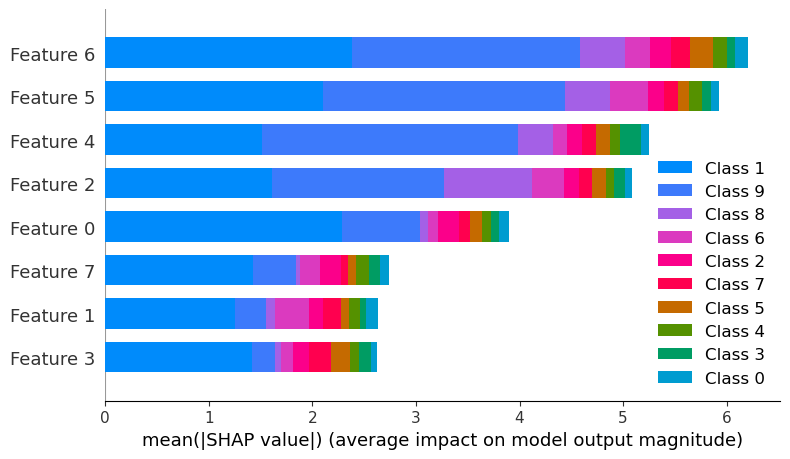

In [95]:
val_dataset = Pool(data=X_test, label=y_test)
explainer = shap.TreeExplainer(cb)
shap_values = explainer.shap_values(val_dataset).transpose(1, 0, 2)
# shap.summary_plot(shap_values, X_test, max_display = 25)

# shap_values = explainer.shap_values(X_eval).transpose(1, 0, 2)

shap.summary_plot(list(shap_values[:, :-1, :-1]),)

In [96]:
shap_values

array([[[ 1.45076689e-02, -9.35371340e-02, -7.35023462e-02, ...,
         -1.10637983e-01, -3.37240311e-02,  1.27684245e-04],
        [-7.91561335e-02,  5.56057481e-02, -3.07170822e-02, ...,
          1.27217942e-02, -4.02533023e-02, -6.88374977e-04],
        [-8.58918454e-02,  9.80195701e-02,  5.62741952e-02, ...,
          1.53543209e-01,  4.95190785e-02,  2.39055802e-06],
        ...,
        [ 8.89274385e-02, -7.42205028e-02, -3.51624015e-02, ...,
         -4.55210605e-02, -5.67393274e-03, -1.79040003e-06],
        [-6.37825855e-04, -5.30508892e-02, -5.76872903e-02, ...,
         -1.00854444e-01,  7.56475964e-04,  1.24662425e-07],
        [-9.84619987e-02,  3.61808297e-02, -1.61670095e-02, ...,
          5.72149135e-02, -4.88344925e-02, -1.24331729e-04]],

       [[-3.54717778e+00,  2.72823336e+00, -1.72020437e+00, ...,
         -2.55846325e+00,  2.97444330e+00, -4.74473357e-03],
        [-3.58197043e+00,  3.38713285e+00, -1.78527038e+00, ...,
         -2.60734792e+00,  3.32464513e

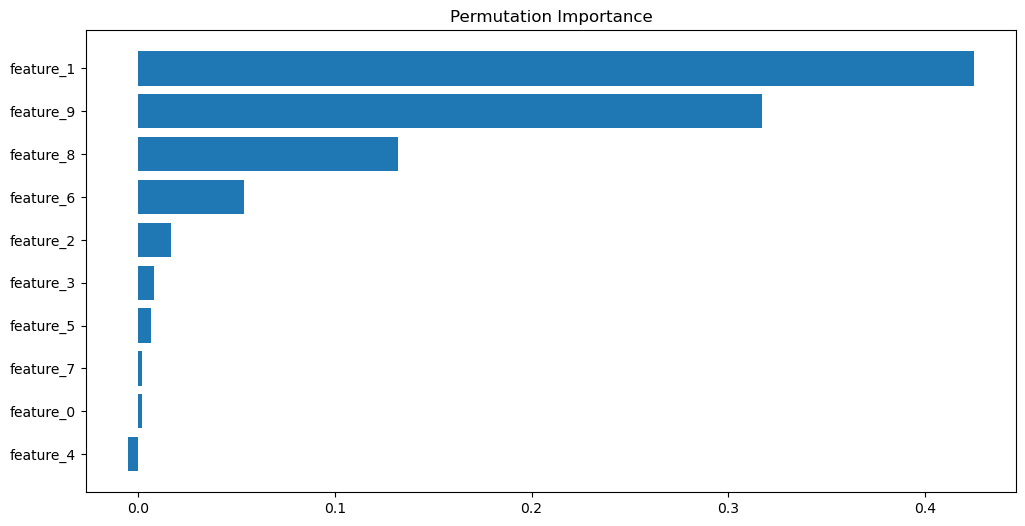

In [97]:
perm_importance = permutation_importance(cb, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm_importance.importances_mean.argsort()
fig = plt.figure(figsize=(12, 6))
plt.barh(range(len(sorted_idx)), perm_importance.importances_mean[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
plt.title('Permutation Importance');

In [98]:
# model = RandomForestClassifier(random_state=42)
# model.fit()

In [99]:
# explainer = shap.TreeExplainer(model)

# shap_values = explainer.shap_values(X_eval).transpose(1, 0, 2)

# shap.summary_plot(list(shap_values[:, :-1, :-1]),)

# Для решения шага 6 в уроке

**🕵️‍♀️ Найди рандомные фичи в датасете***

Датасет

In [100]:
import pandas as pd
path = '../data/fs_task2_22f.csv'
df = pd.read_csv(path)
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target_reg,target_class
0,0,4.101552,173,1,3.405865,88182,157.168032,1.973071e+07,0,1,...,2015,191.996603,2020,0.1,0,174,9,4.76,57.15,engine_ignition
1,0,4.303506,173,1,-2.218952,86897,121.805143,1.594185e+07,0,0,...,2015,193.547718,2015,0.1,1,174,7,4.26,60.82,engine_ignition
2,0,4.246379,174,1,-3.740321,44604,175.889164,2.127630e+07,0,0,...,2013,177.922027,2019,0.1,1,174,6,5.98,46.51,engine_ignition
3,0,4.342874,172,1,3.139031,114610,151.653445,2.250440e+07,0,0,...,2017,110.165268,2016,0.7,1,174,20,4.42,30.71,gear_stick
4,1,4.140287,148,0,-4.022916,114851,159.547387,1.163474e+07,0,0,...,2017,190.915943,2020,0.1,0,174,25,4.28,59.18,engine_fuel


Ваша задача: Провести расследование, используя любые методы из урока, и найти названия рандомных фичей.
Например: Если выяснилось, что рандомными являются feature_2 и feature_10, то следует в поле ответа внести их названия в список answer.




Формат ответа


In [101]:
answer = ['feature_6', 'feature_11']

! порядок НЕ важен!

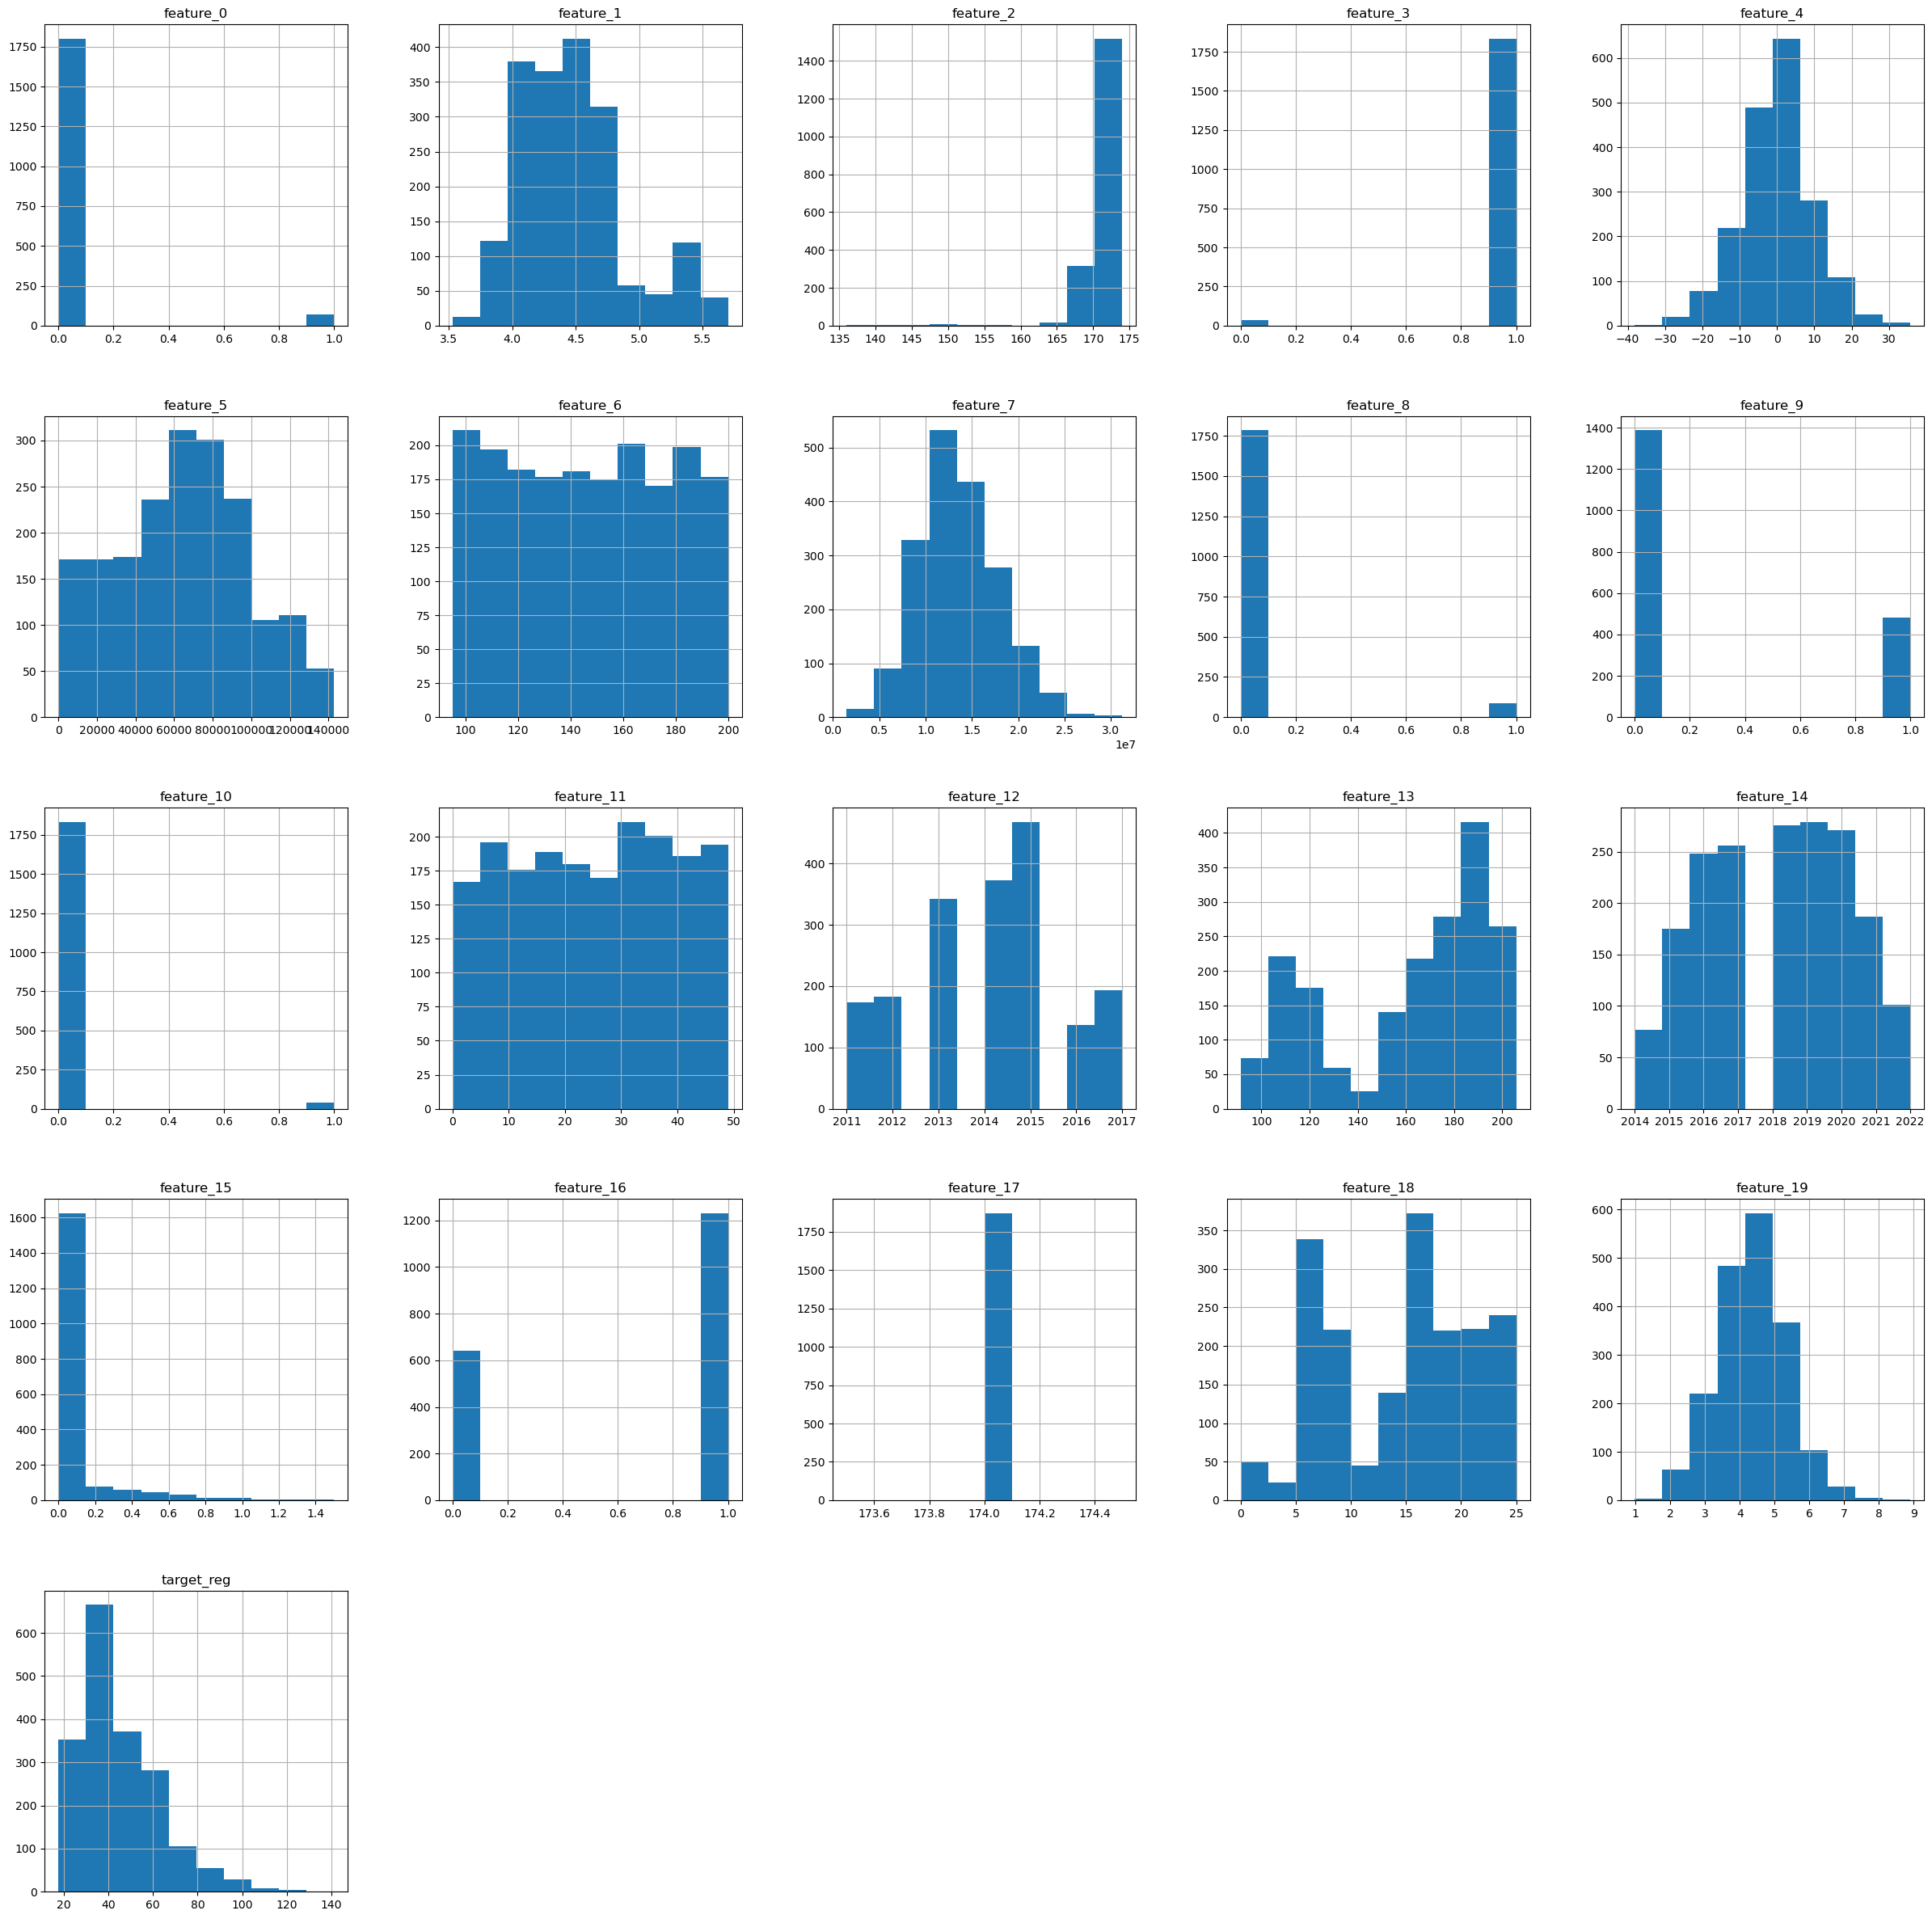

In [102]:
df.hist(figsize=(30, 30))

plt.show();

In [103]:
phik_overview = phik.phik_matrix(df=df, njobs=-1).round(2)
phik_overview[['target_reg', 'target_class']].sort_values(by=['target_reg', 'target_class'], ascending=[True, True])

interval columns not set, guessing: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'target_reg']


,target_reg,target_class
feature_6,0.00,0.00
feature_11,0.00,0.00
feature_5,0.00,0.01
feature_19,0.00,0.03
feature_12,0.00,0.06
feature_7,0.00,0.10
feature_4,0.00,0.11
feature_9,0.00,0.17
feature_14,0.06,0.00
feature_15,0.10,0.31


# Для решения шага 8 в уроке

**🤯 Отранжируй признаки, если их ооочень много**

Датасет

In [122]:
path = '../data/fs_task3_310f.csv'
df = pd.read_csv(path)
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_301,feature_302,feature_303,feature_304,feature_305,feature_306,feature_307,feature_308,feature_309,target
0,-0.917,-0.313,-0.69,0.771,0.086,44800,1.38,42902,-0.40,0.51,...,49118,43122,-0.99,-0.68,-0.07,8006,-0.166,0.40,173,gear_stick
1,1.406,0.324,0.88,0.104,1.275,2097,-0.53,19640,0.25,1.12,...,23477,26027,0.20,0.24,-0.13,9512,0.816,1.28,173,wheel_shake
2,0.908,0.652,0.62,0.482,0.768,21520,0.88,7491,1.07,0.58,...,19738,5099,1.53,0.18,0.69,35420,0.994,0.16,170,break_bug
3,-0.527,-0.892,-0.12,-0.764,-0.811,7649,0.61,12421,-1.78,0.21,...,27290,17042,-1.84,-0.76,-0.10,36626,0.867,-2.71,170,another_bug
4,0.050,0.646,-2.51,0.510,-0.755,27745,0.00,38967,1.08,1.46,...,43419,6234,-0.97,-0.62,0.91,35750,0.076,-0.07,173,electro_bug


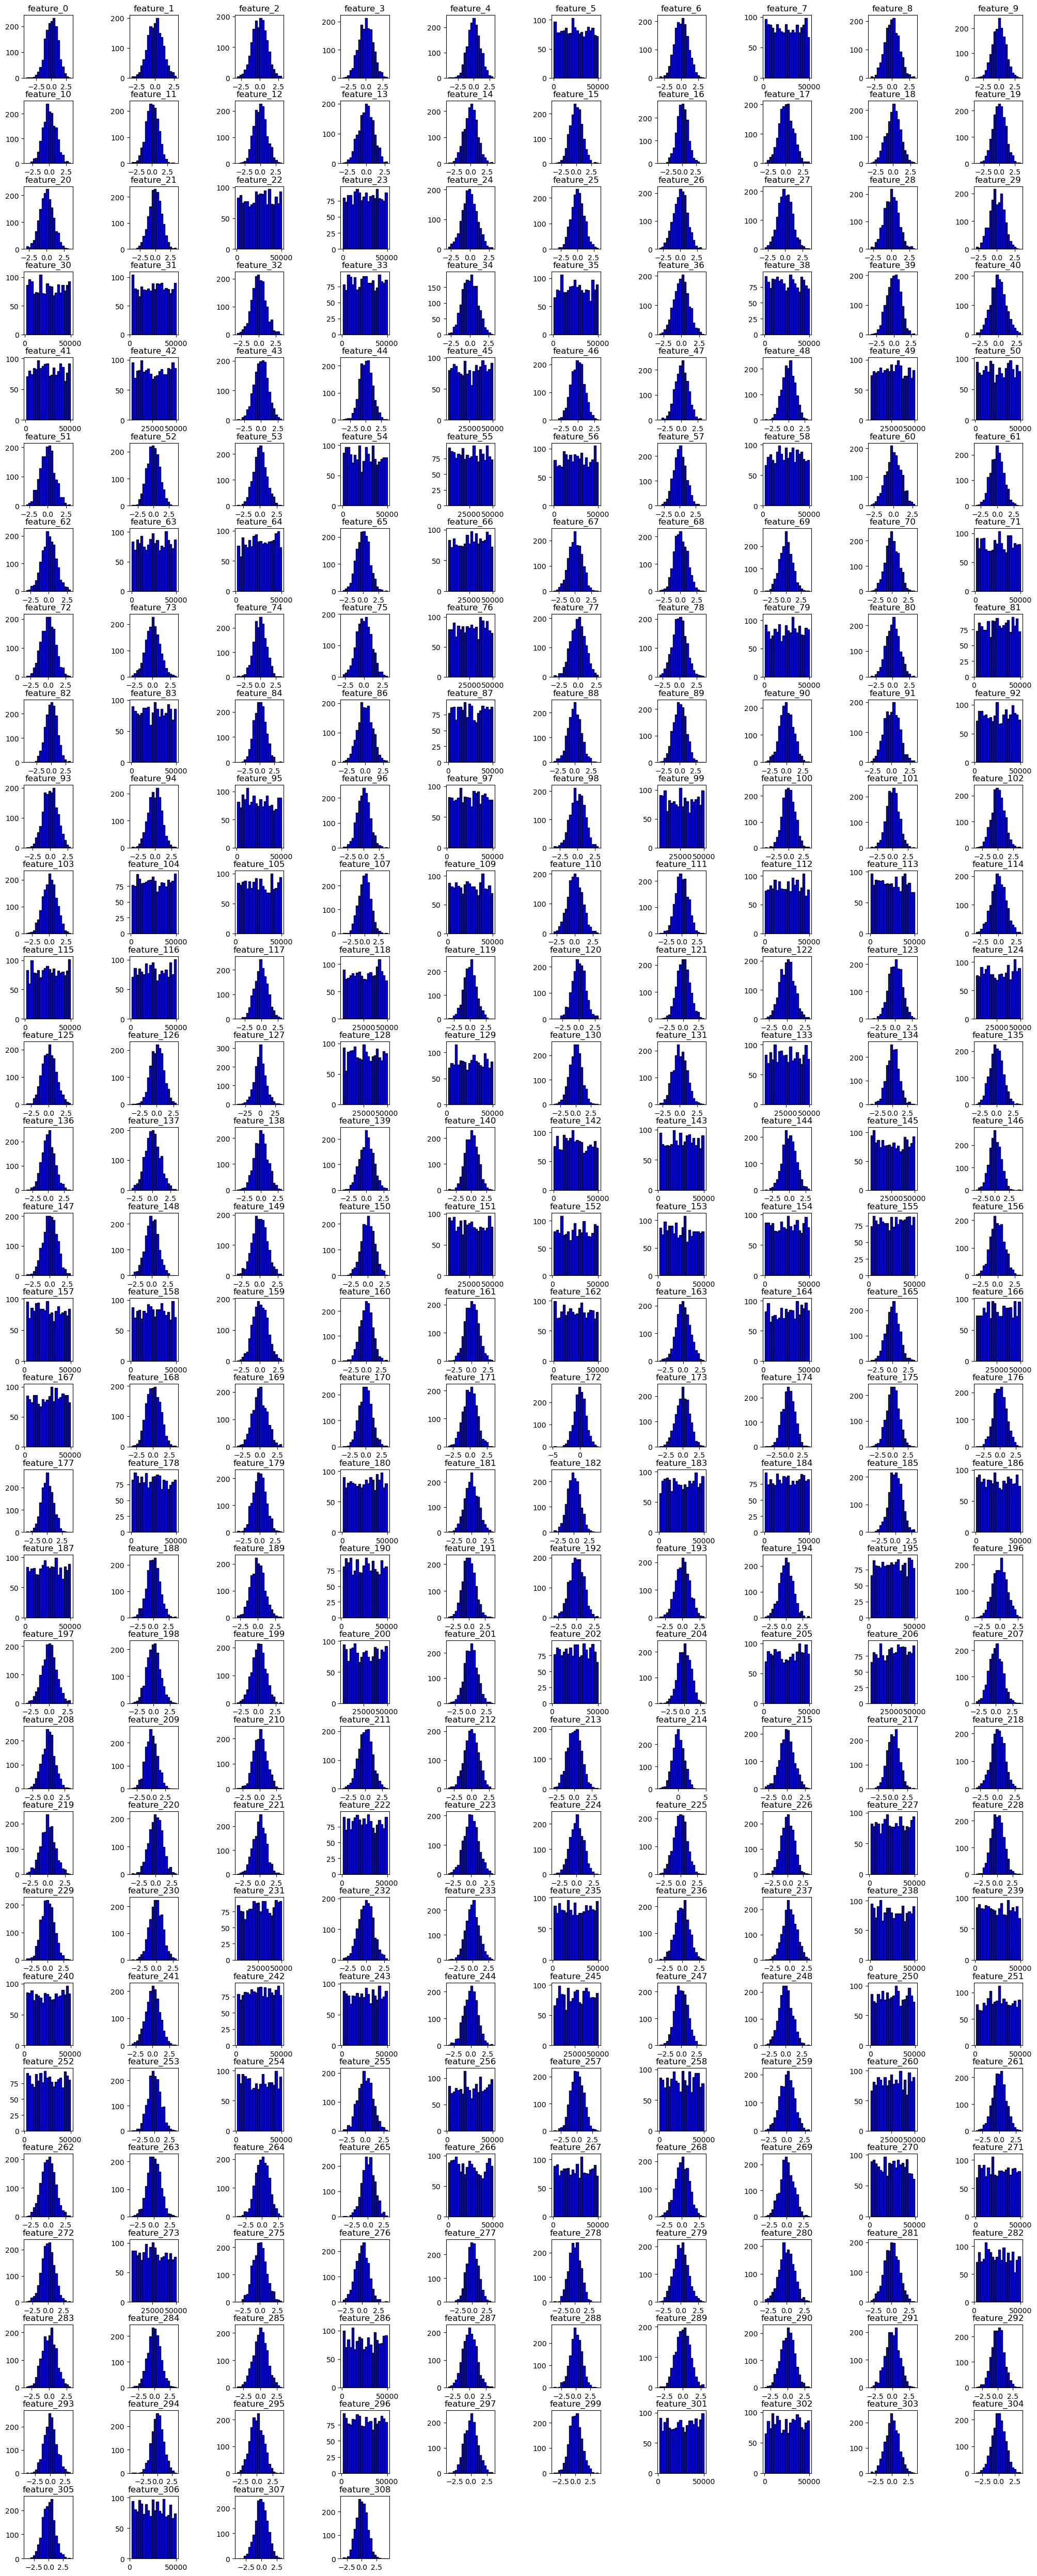

In [123]:
plt.figure(figsize=(20, 50))

cols = ['feature_141', 'feature_234', 'feature_59', 'feature_309', 'feature_203', 'feature_108', 'feature_132', 'feature_274',
       'feature_246', 'feature_298', 'feature_106', 'feature_85', 'feature_37', 'feature_249', 'feature_216', 'feature_300', 'target']

col_selected = [col for col in df.columns if col not in cols]

for i, feature in enumerate(col_selected):

    # Set up the plot
    ax = plt.subplot(len(col_selected) // 10 + 1, 10, i + 1)

    # Draw the plot
    ax.hist(df[feature], color = 'blue', edgecolor = 'black', bins=20)

    ax.set_title(feature)

plt.tight_layout(h_pad=0.01, w_pad=5)
plt.show();

In [124]:
pd.set_option('display.max_rows', 500)

In [125]:
pd.reset_option('^display.')

In [126]:
df[col_selected].describe().T.sort_values('mean')

,count,mean,std,min,25%,50%,75%,max
feature_127,1636.0,-0.288754,9.589478,-38.116345,-6.17480,-0.268192,5.577506,35.770493
feature_24,1636.0,-0.068380,0.977650,-2.850000,-0.72000,-0.080000,0.582500,2.960000
feature_230,1636.0,-0.061604,0.981069,-3.734000,-0.72825,-0.071000,0.624000,2.990000
feature_225,1636.0,-0.055532,0.987982,-3.150000,-0.71250,-0.035000,0.612500,3.460000
feature_170,1636.0,-0.051693,0.987624,-3.614000,-0.74800,-0.059000,0.596000,3.370000
...,...,...,...,...,...,...,...,...
feature_231,1636.0,26725.389364,13729.886140,2443.000000,15286.25000,26827.500000,38764.250000,49976.000000
feature_124,1636.0,26733.415648,13844.352484,2768.000000,14587.00000,27004.500000,39008.750000,49985.000000
feature_166,1636.0,26774.589242,13553.725025,2734.000000,15135.75000,26478.000000,38418.500000,49993.000000
feature_66,1636.0,26834.201711,13580.814643,2676.000000,15300.75000,27171.500000,38501.750000,49990.000000


In [127]:
# Выявленные:

# feature_141 +++
# feature_234 +++
# feature_59 +++
# feature_309 +++
# feature_203 +++
# feature_108 +++
# feature_132 +++
# feature_246 +++
# feature_274 +++
# feature_127 +++

# Точно лишние:

# feature_298 -
# feature_106 - 
# feature_85 -
# feature_37 -
# feature_249 -
# feature_216 -
# feature_300 -

In [128]:
# feature_141 +++
# feature_234 +++
# feature_59 +++
# feature_309 +++
# feature_203 +++
# feature_108 +++
# feature_132 +++
# feature_246 +++
# feature_274 +++
# feature_127 +++
# feature_298 -
# feature_106 - 
# feature_85 -
# feature_37 -
# feature_249 -
# feature_216 -
# feature_300 -

In [129]:
phik_overview = phik.phik_matrix(df=df, njobs=-1).round(2)
phik_target = phik_overview[['target']].sort_values(by=['target'], ascending=False)

interval columns not set, guessing: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_67', 'feature_68', 'featur

In [130]:
phik_target[1: 11]

# plot_correlation_matrix(phik_overview.values, 
#                         x_labels=phik_overview.columns, 
#                         y_labels=phik_overview.index, 
#                         vmin=0, vmax=1, color_map="Greens", 
#                         title=r"correlation $\phi_K$", 
#                         fontsize_factor=0.8, figsize=(11, 6))
# plt.tight_layout()

# plt.show();

,target
feature_141,0.78
feature_234,0.63
feature_59,0.30
feature_309,0.23
feature_203,0.14
feature_297,0.13
feature_127,0.11
feature_85,0.11
feature_122,0.10
feature_37,0.10


In [131]:
# !pip install BorutaShap

In [7]:
df = pd.read_csv('../data/fs_task3_310f.csv')
TARGET = 'target'

y = df[TARGET]
X = df.drop(TARGET, axis=1)

model = RandomForestClassifier(random_state=42, n_jobs=-1)
Feature_Selector = BorutaShap(model=model,
                              importance_measure='shap',
                              classification=True)
Feature_Selector.fit(X=X, y=y, n_trials=50, random_state=0)

  0%|          | 0/50 [00:00<?, ?it/s]

IndexError: list index out of range

Попробуй найти заветную десятку. За каждый правильный ответ получишь балл.

У тебя всего 10 попыток. Пока система проверяет решение, не надо дополнительно нажимать "Отправить", т. к. сгорают попытки!!!

Формат вывода ответа

In [ ]:
# import shap
# import numpy as np
# import pandas as pd
# from sklearn.ensemble import RandomForestClassifier

# df = pd.read_csv('../data/fs_task3_310f.csv')
# TARGET = 'target'

# y = df[TARGET]
# X = df.drop(TARGET, axis=1)

# # Обучите модель
# model = RandomForestClassifier(random_state=42, n_jobs=-1)
# model.fit(X, y)

# # Получите SHAP-значения
# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X)


# # Отберите признаки по средней абсолютной SHAP
# if isinstance(shap_values, list):
#     # Для мультиклассовой классификации
#     shap_abs = np.array([np.abs(sv) for sv in shap_values])
#     importance = np.mean(shap_abs, axis=(0, 1))
# else:
#     # Для бинарной/регрессии
#     importance = np.mean(np.abs(shap_values), axis=0)

# # Явно приводим к 1D-массиву
# # importance = np.ravel(importance)  # преобразуем в 1D
# sorted_idx = np.argsort(importance)[::-1]
# top_n = 10

# # Преобразуем столбцы в простой массив строк
# top_features = X.columns.values[sorted_idx[:top_n]].astype(str)

# # Вывод
# print('Топ-10 наиболее важных признаков (по SHAP):')
# for i, feature in enumerate(top_features, 1):
#     # Берём значение важности по индексу
#     imp_value = importance[sorted_idx[i-1]]
#     print(f'{i}. {feature} (важность: {imp_value:.4f})')


Топ-10 наиболее важных признаков (по SHAP):


TypeError: unsupported format string passed to numpy.ndarray.__format__

In [33]:
#Фильтрация признаков по их максимуму
df_max = df.describe().iloc[7,:].to_frame()
df_clear = df[list(df_max[~(df_max['max'].between(49000, 50000, inclusive='both'))][~(df_max['max'].between(2.5, 5, inclusive='both'))].index)+['target']]
df_clear.head()

,feature_59,feature_106,feature_108,feature_127,feature_132,feature_141,feature_203,feature_234,feature_246,feature_274,feature_298,feature_309,target
0,0.10,2021,2017,10.994330,122855,105.447235,8.279094e+06,44.114943,2021,3.06,2013,173,gear_stick
1,0.10,2012,2013,-1.945853,45026,134.593183,1.770102e+07,44.574713,2016,3.46,2019,173,wheel_shake
2,0.15,2017,2015,-12.777499,76964,114.037719,1.672311e+07,44.580460,2020,5.42,2015,170,break_bug
3,0.10,2019,2011,-5.000201,1456,183.654473,1.274463e+07,45.224138,2020,2.84,2018,170,another_bug
4,0.00,2011,2014,1.740015,65210,183.998367,1.480847e+07,50.143678,2016,4.62,2021,173,electro_bug


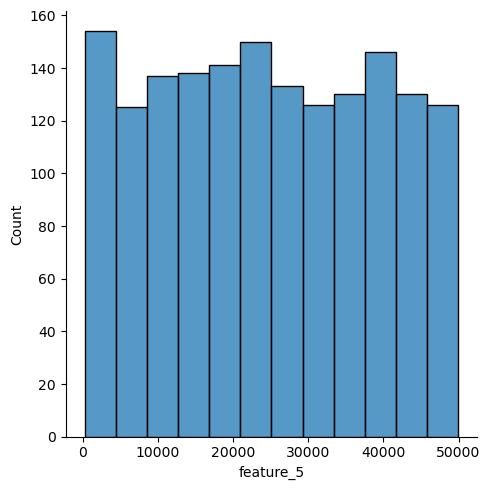

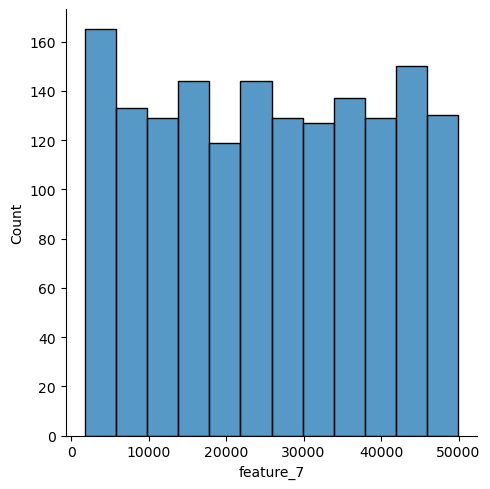

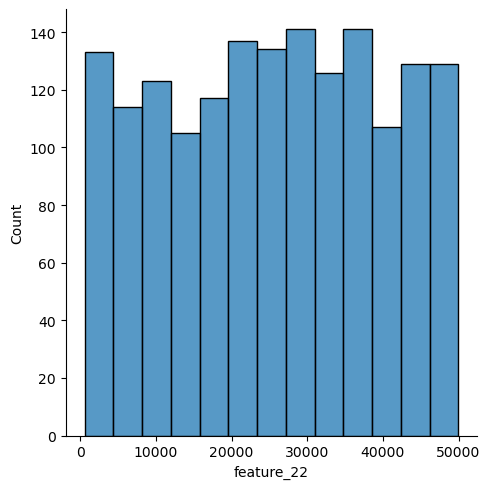

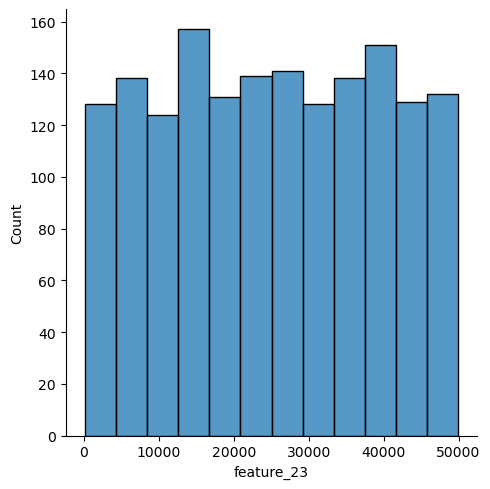

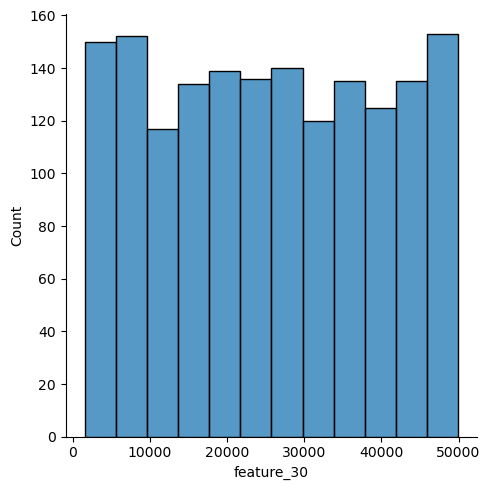

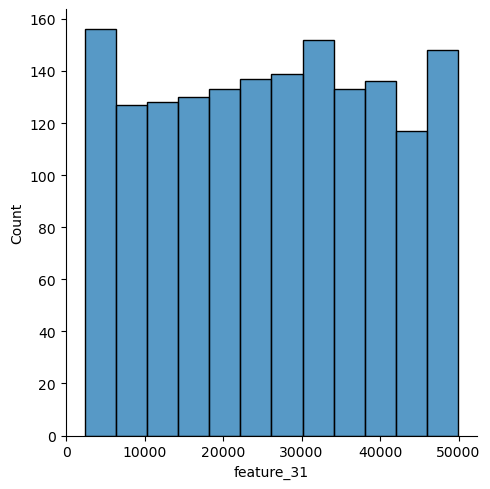

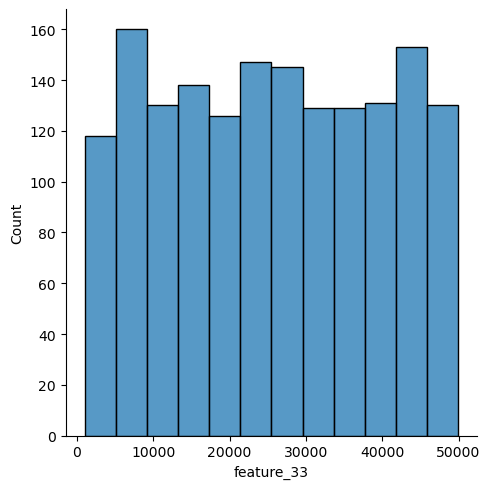

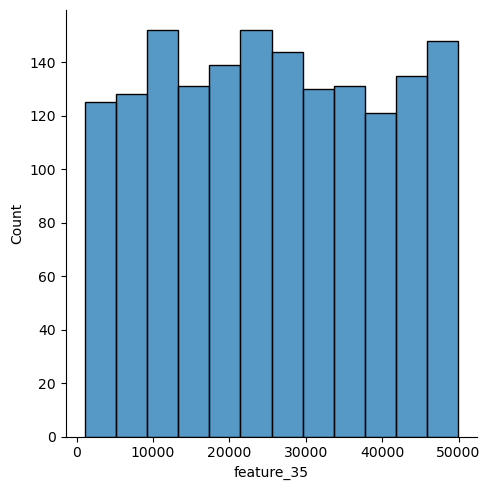

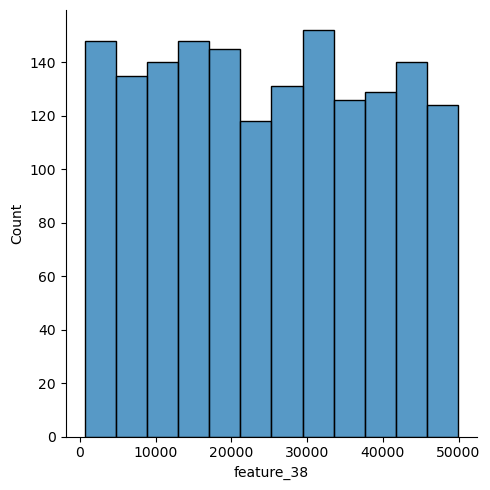

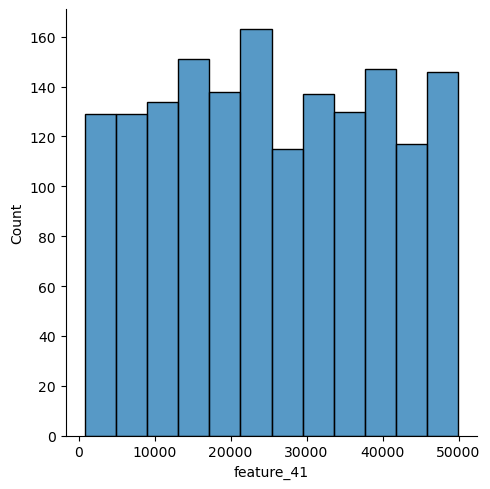

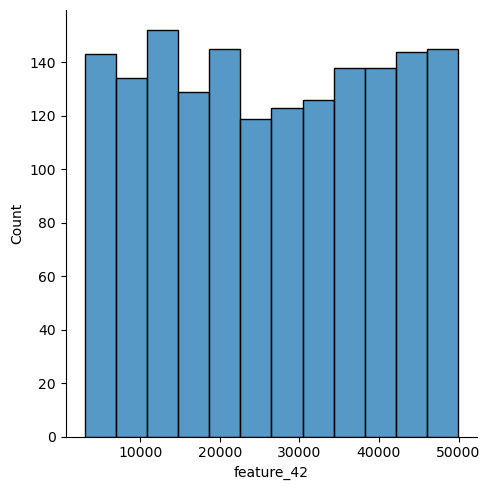

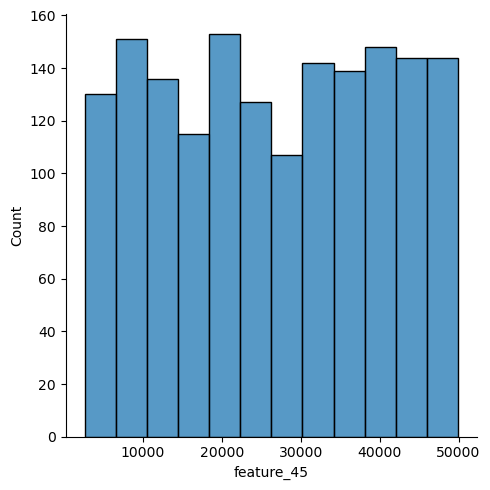

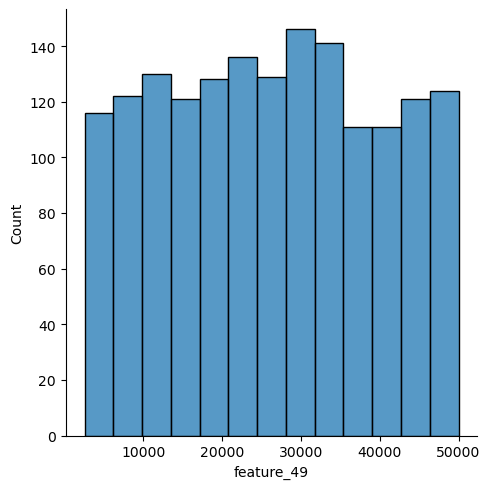

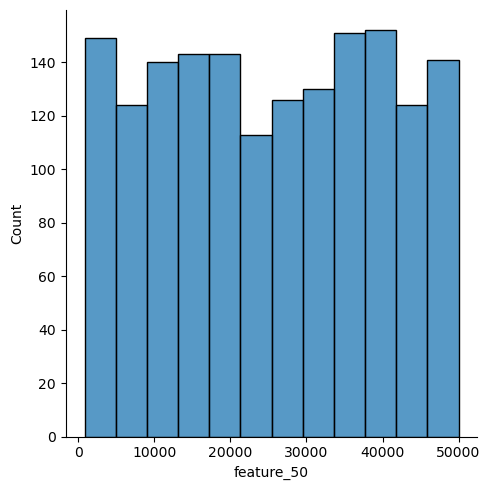

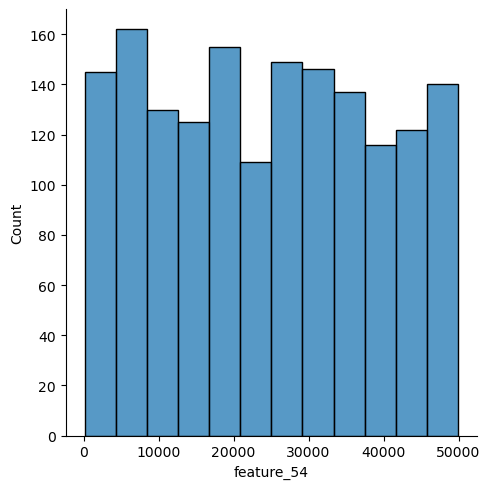

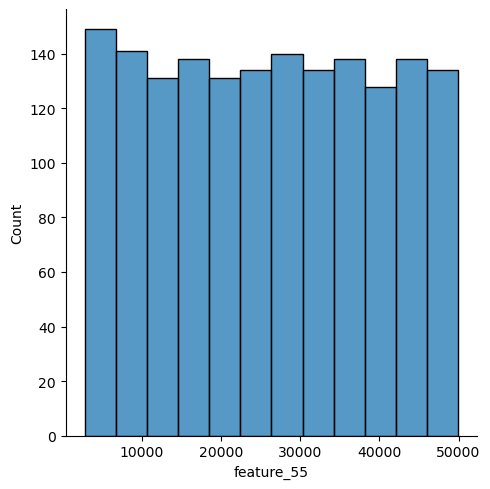

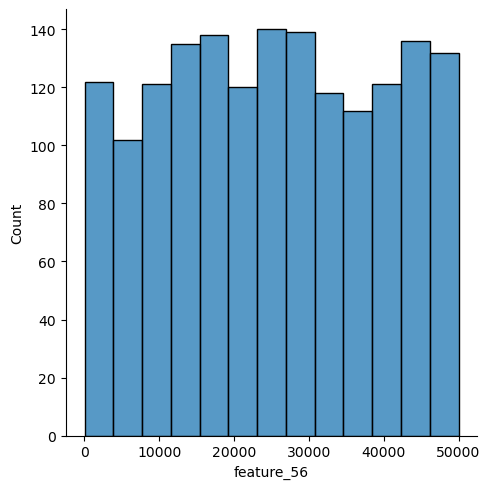

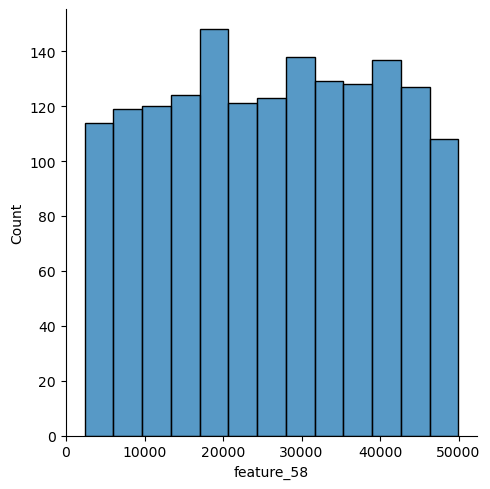

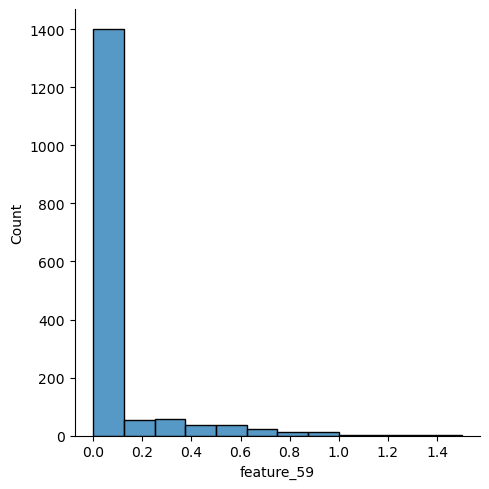

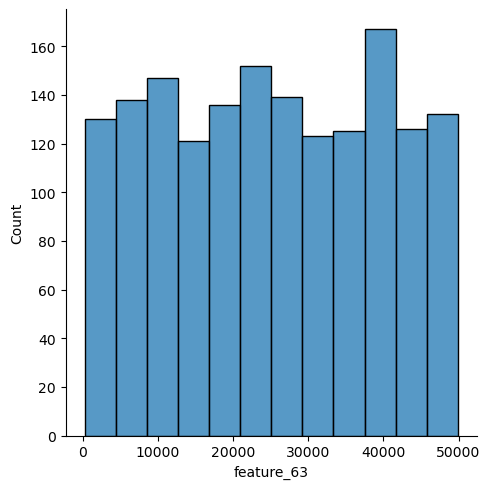

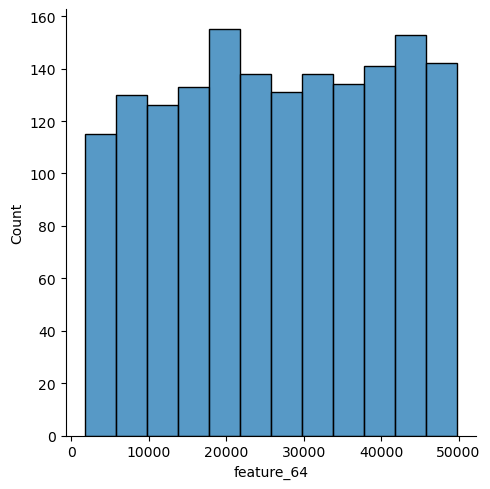

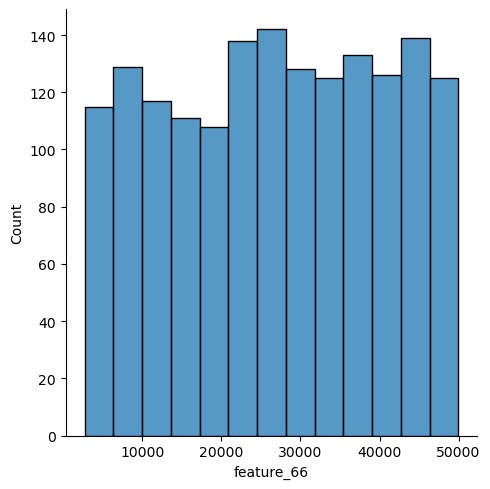

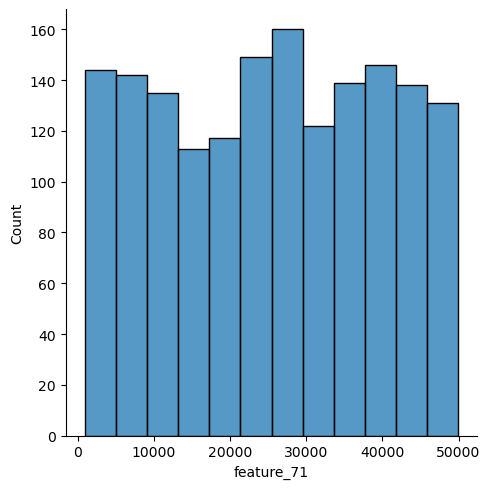

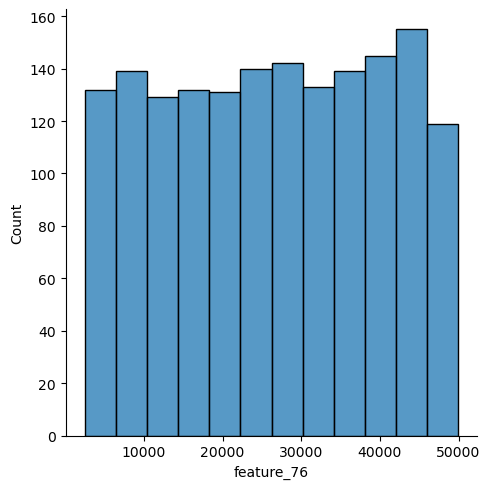

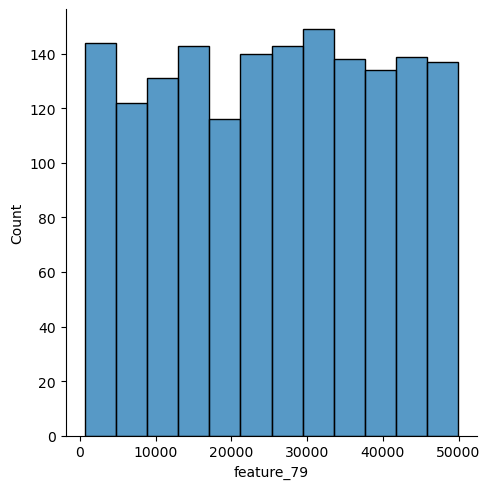

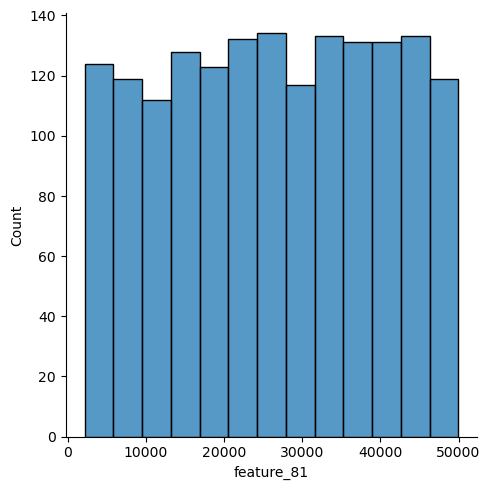

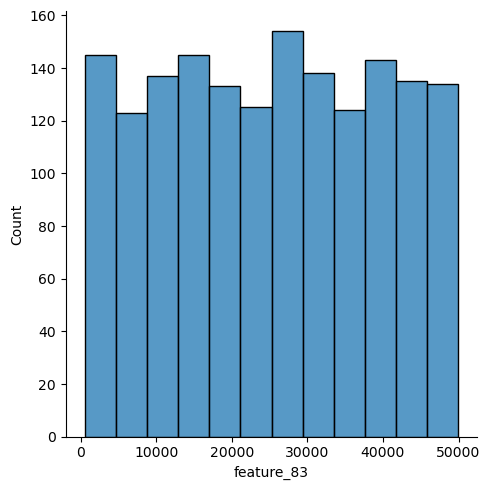

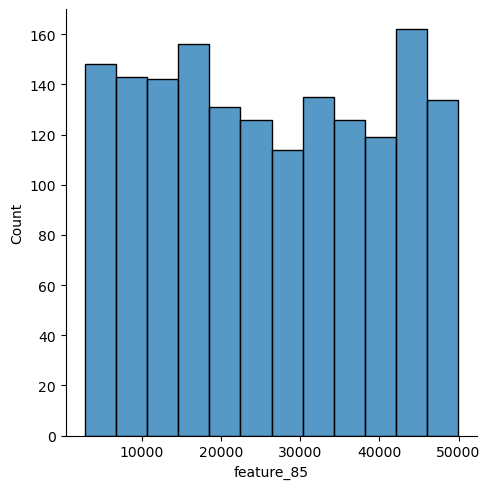

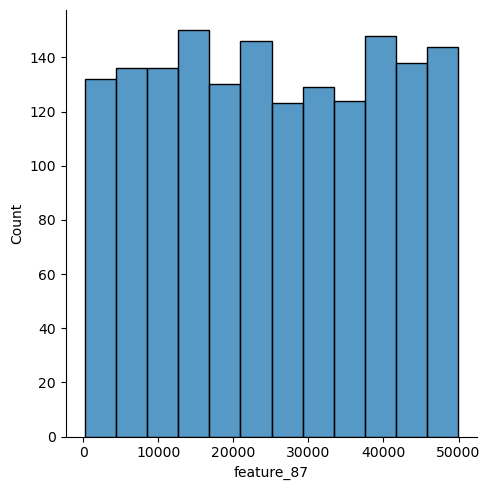

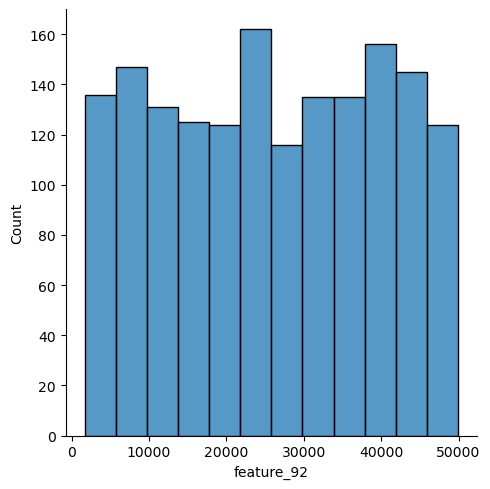

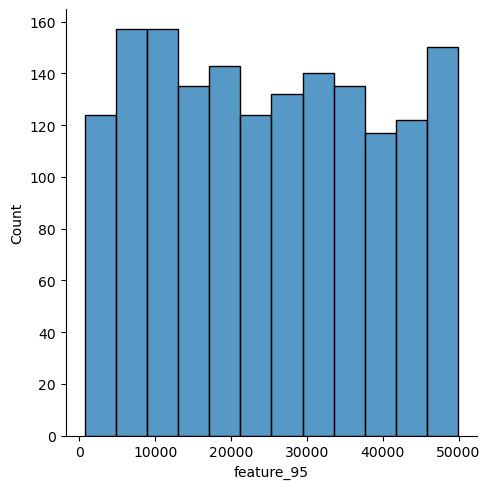

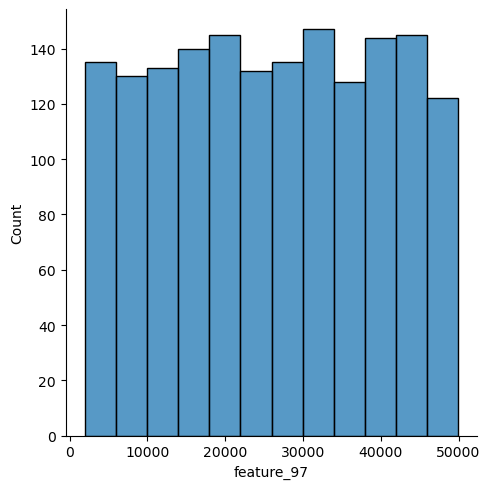

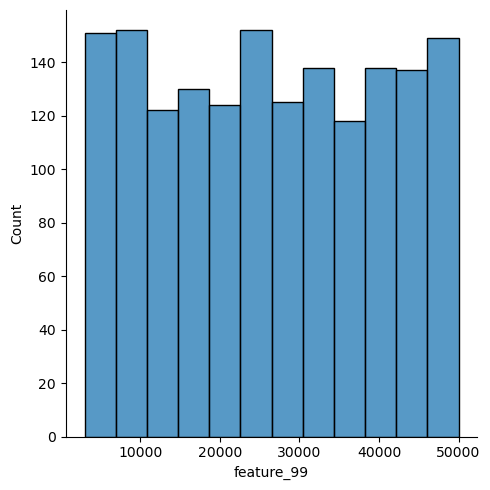

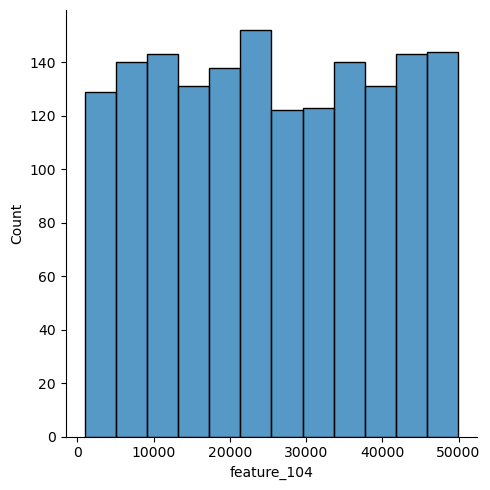

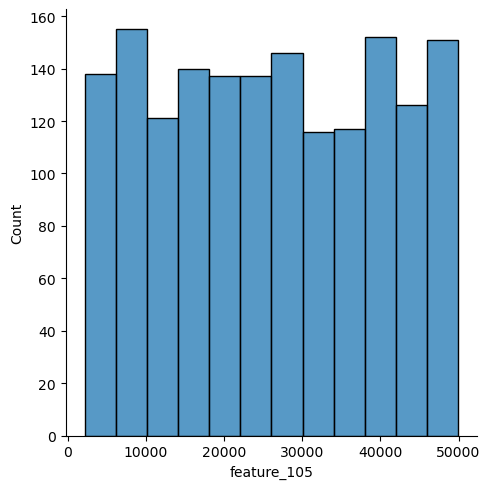

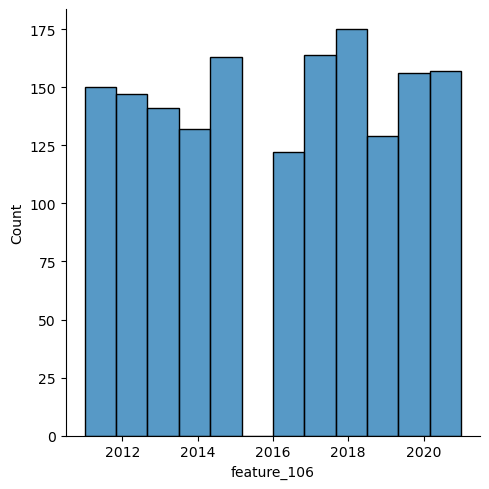

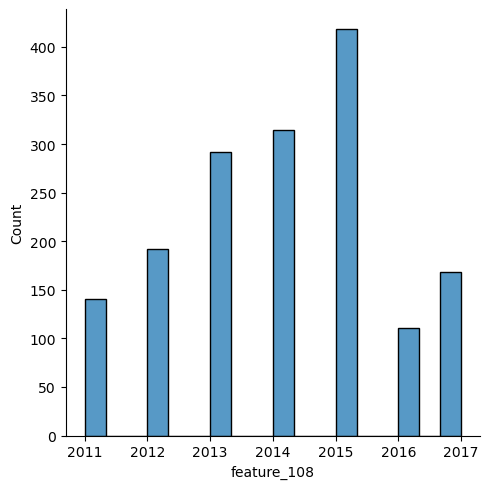

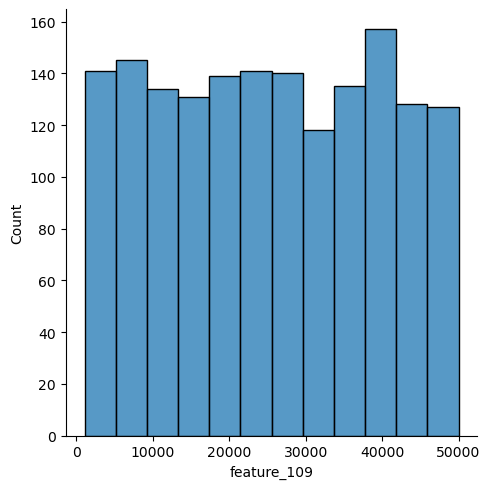

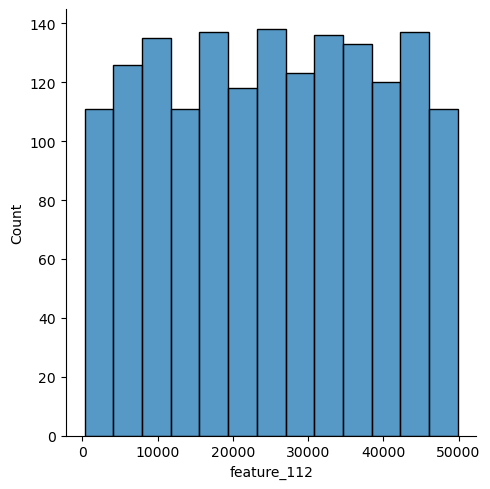

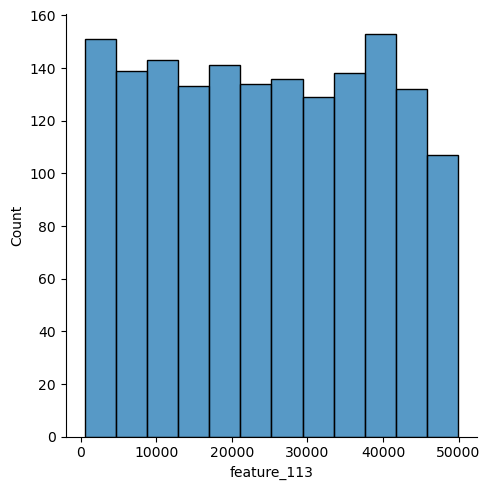

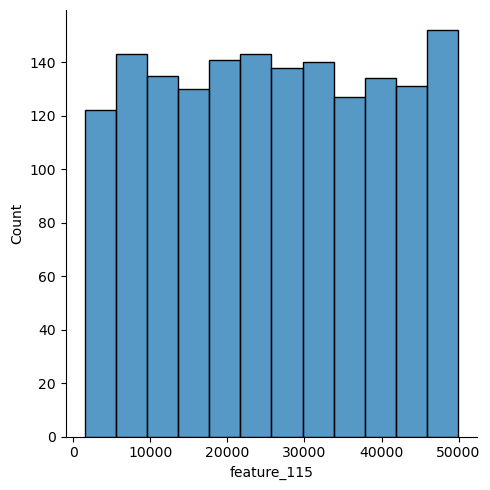

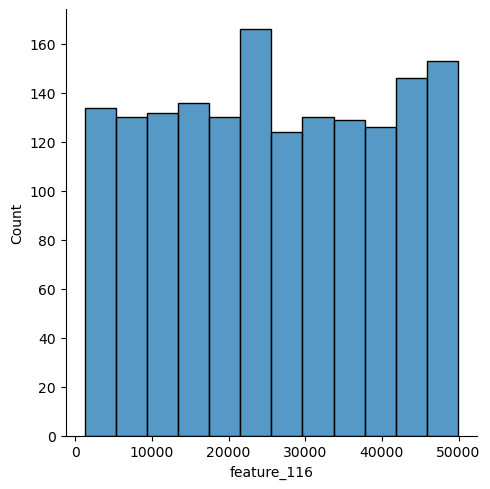

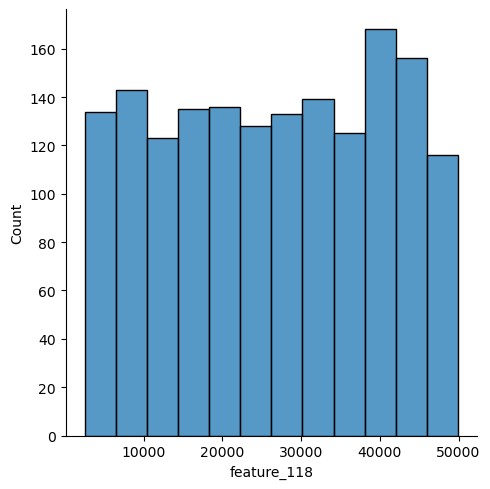

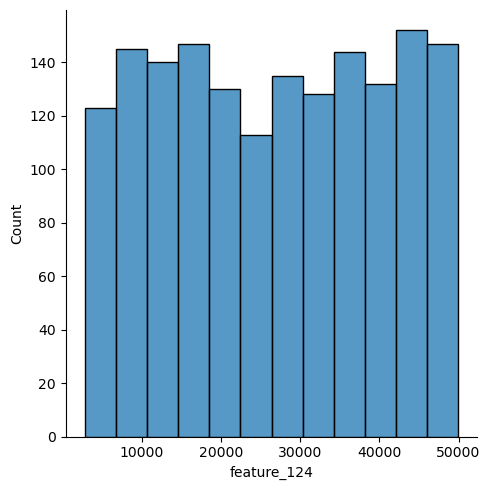

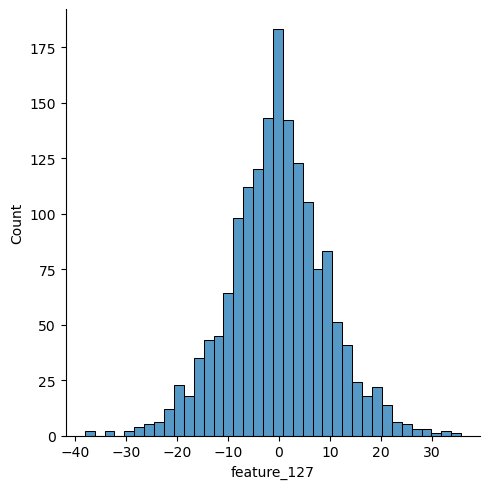

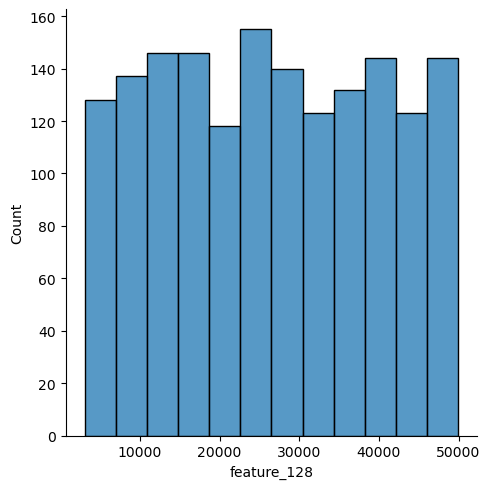

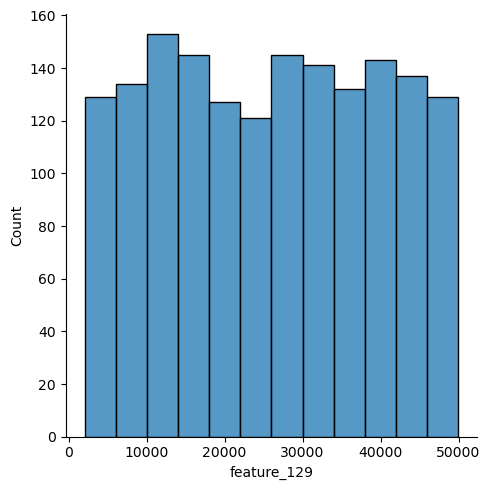

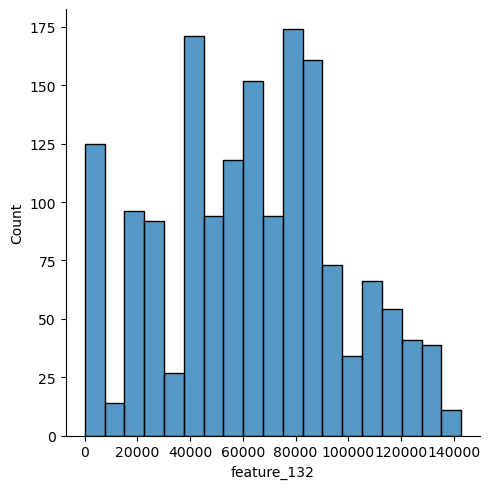

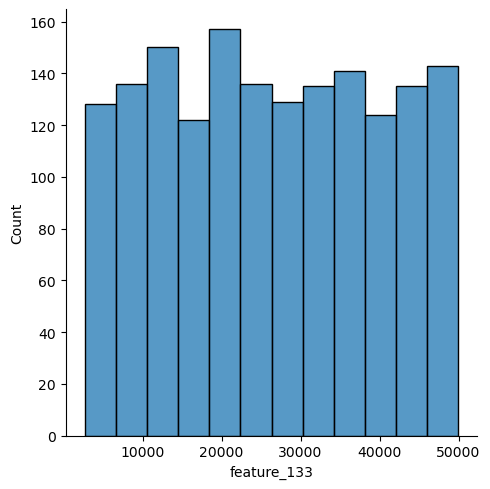

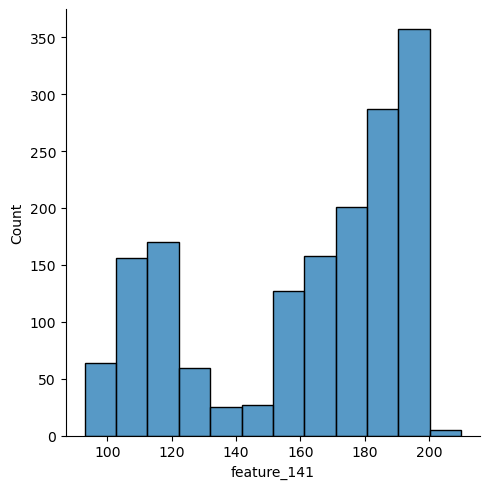

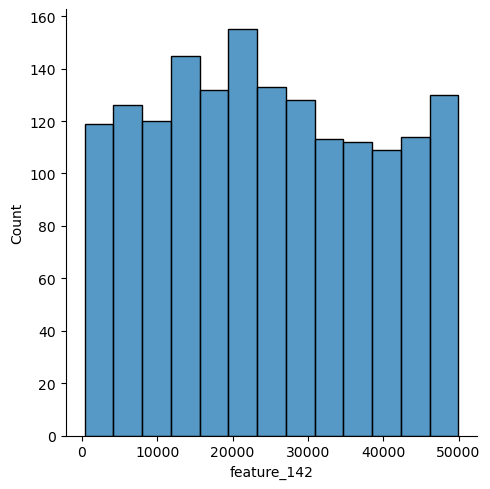

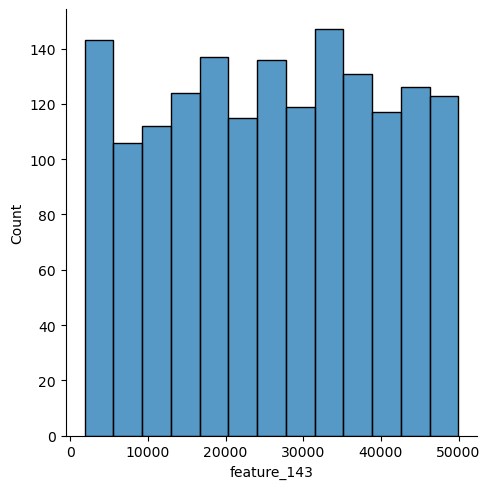

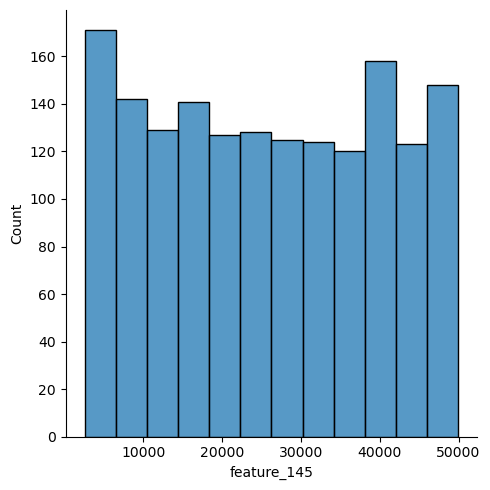

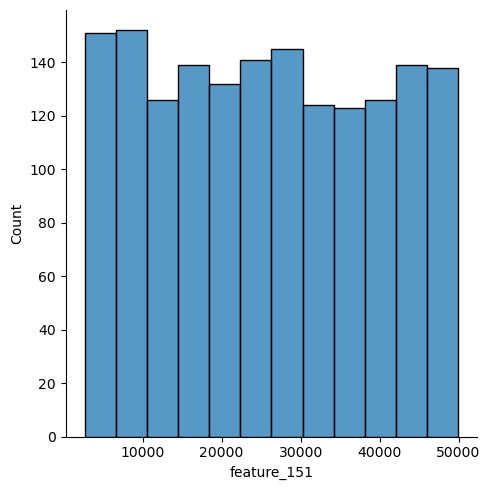

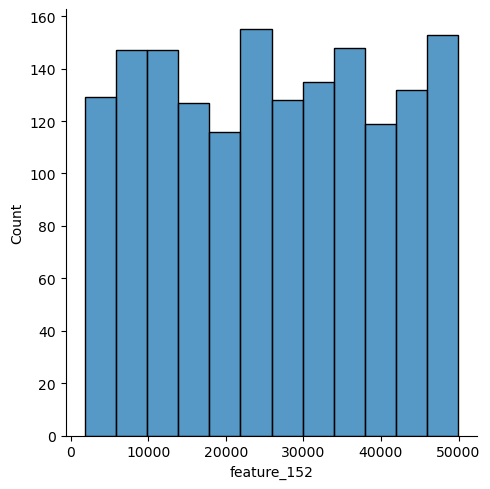

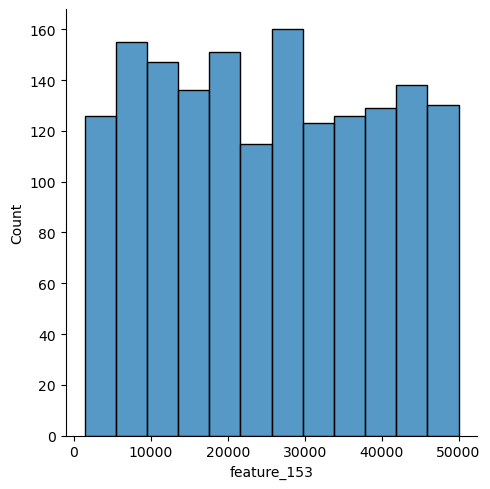

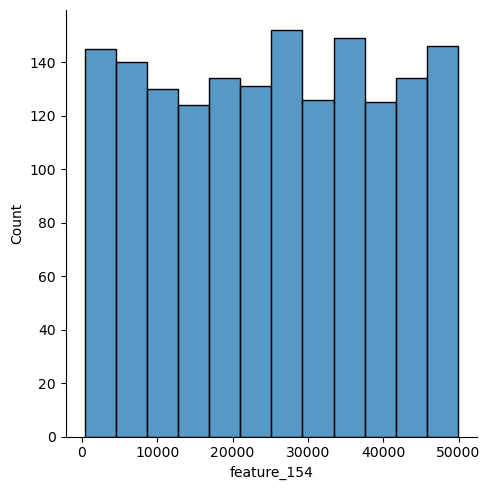

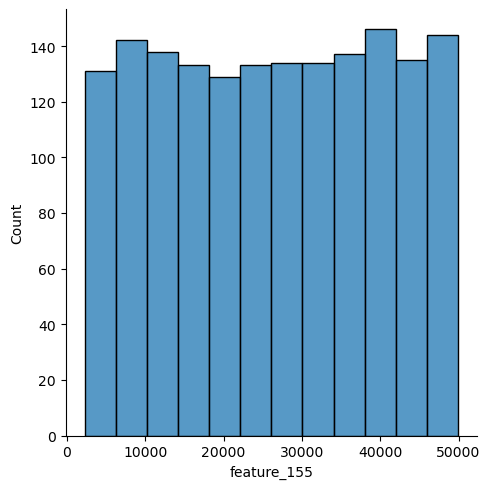

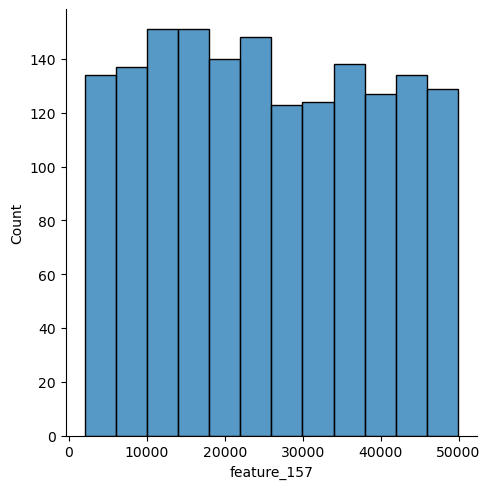

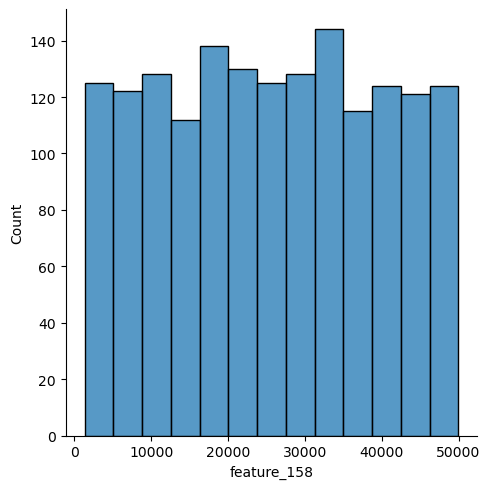

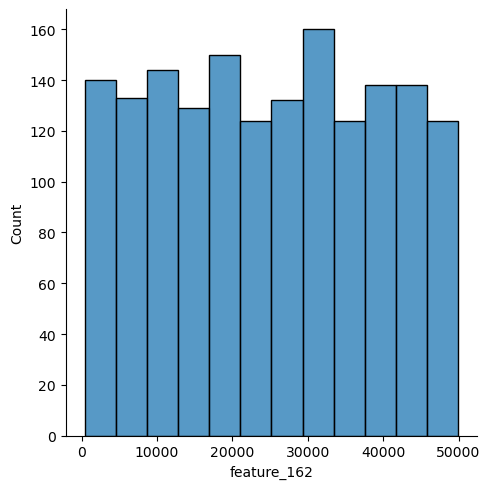

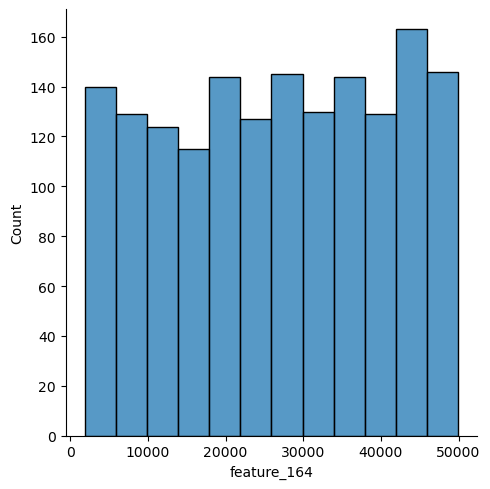

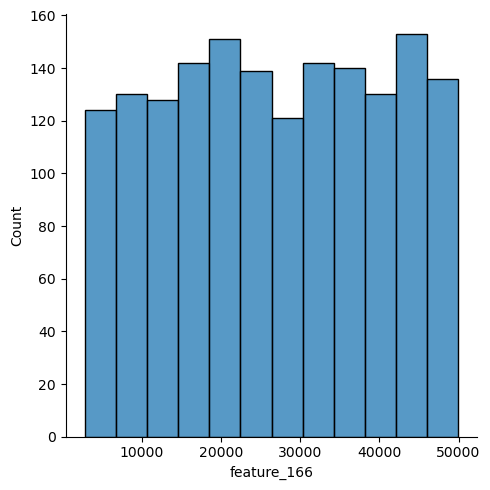

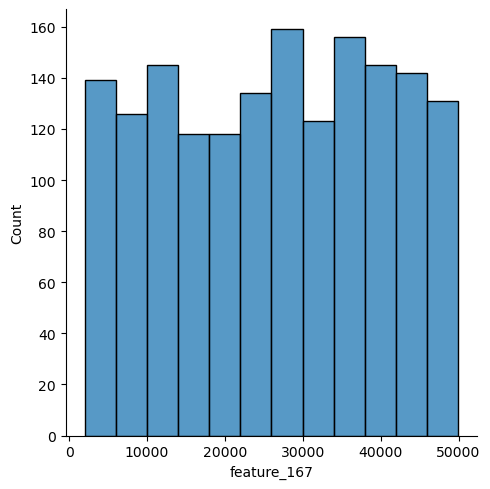

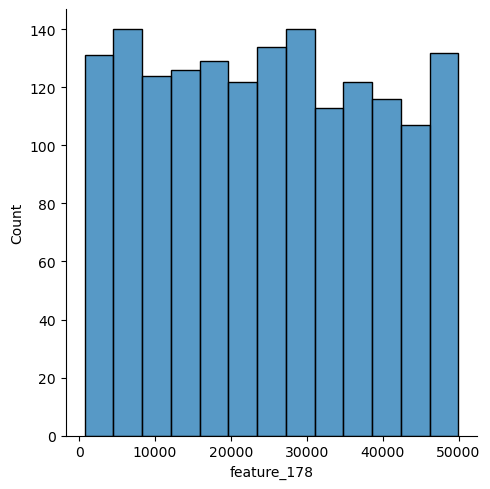

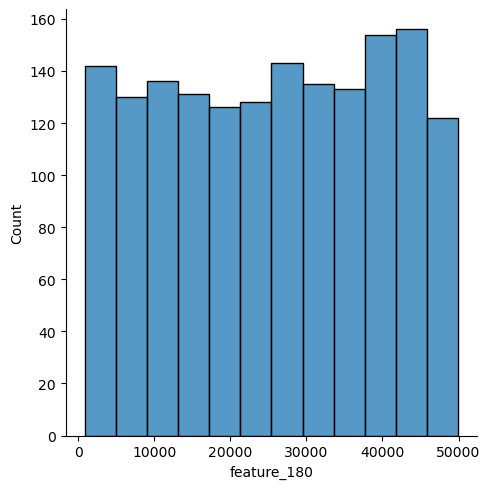

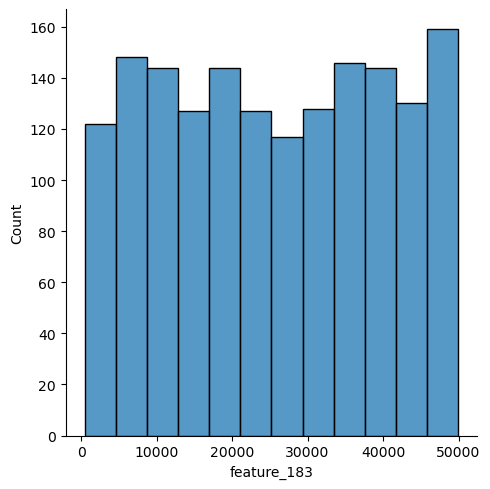

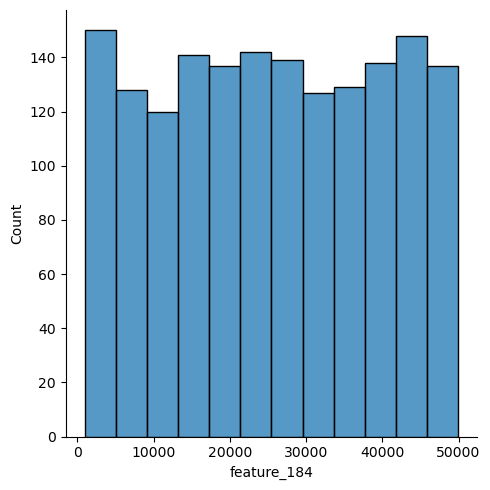

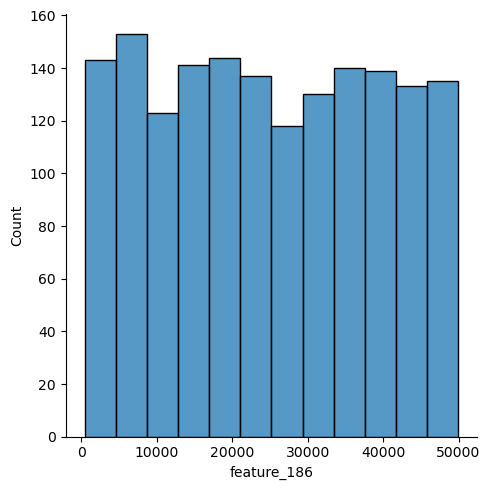

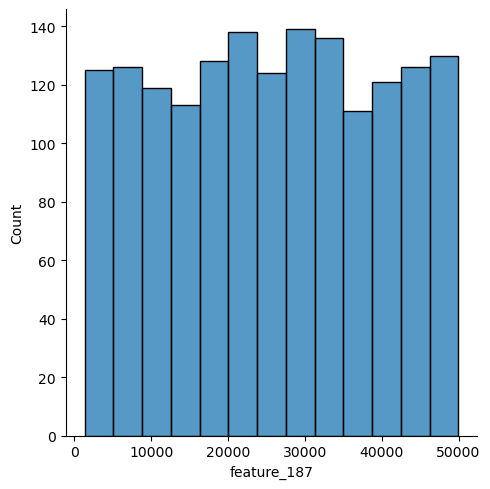

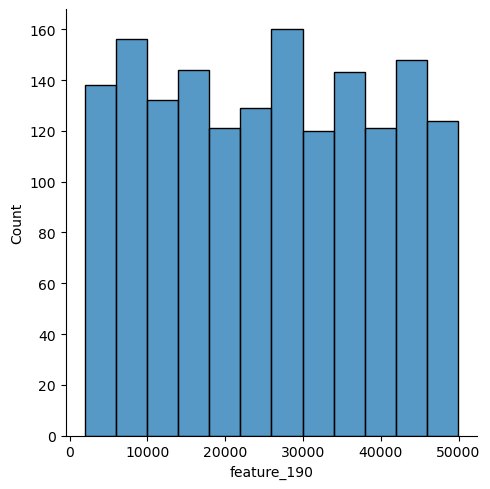

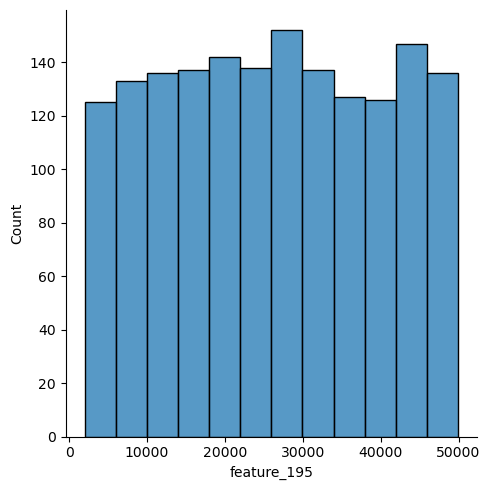

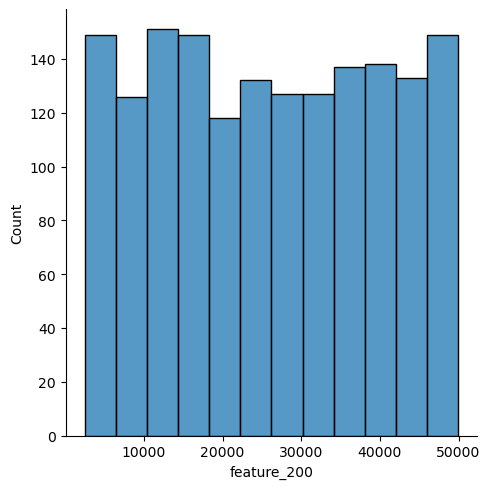

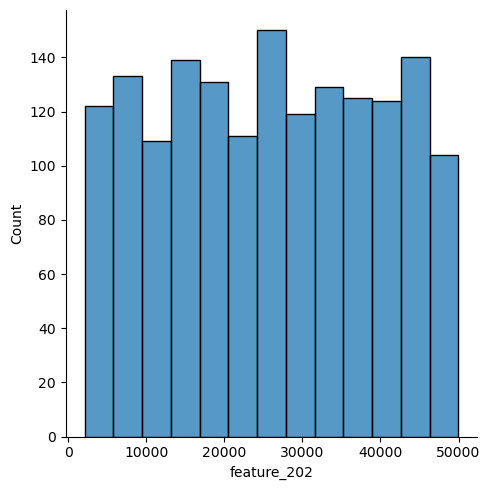

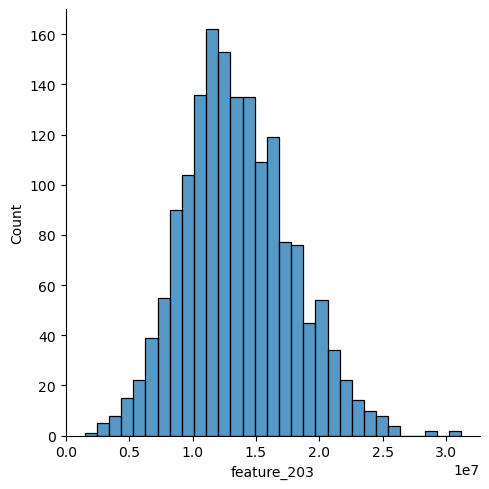

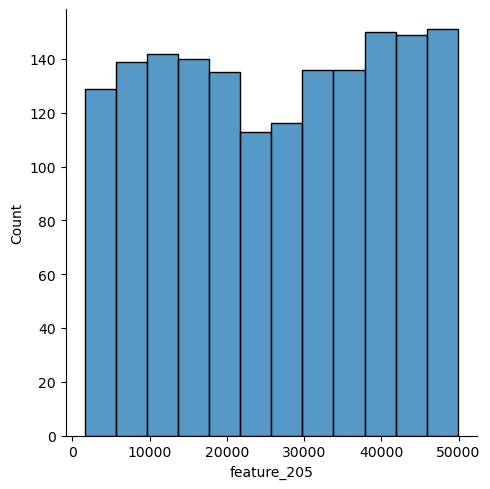

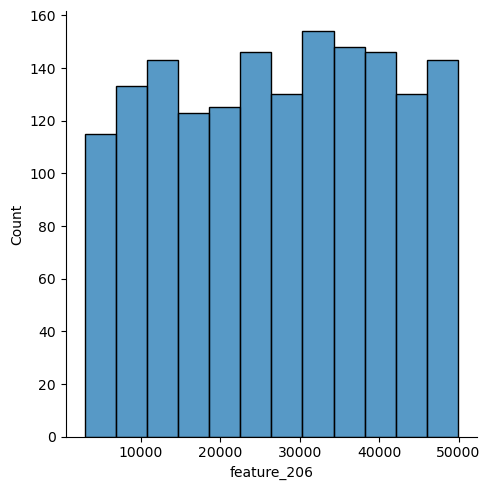

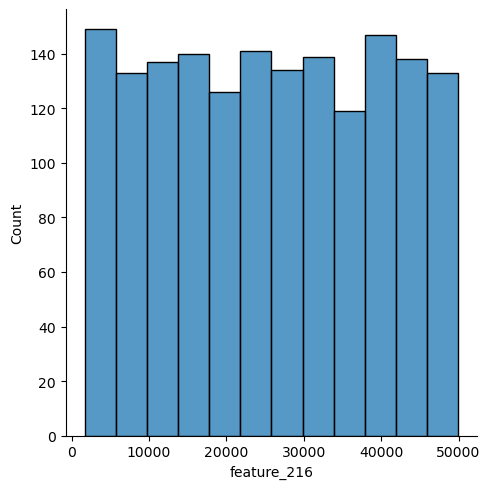

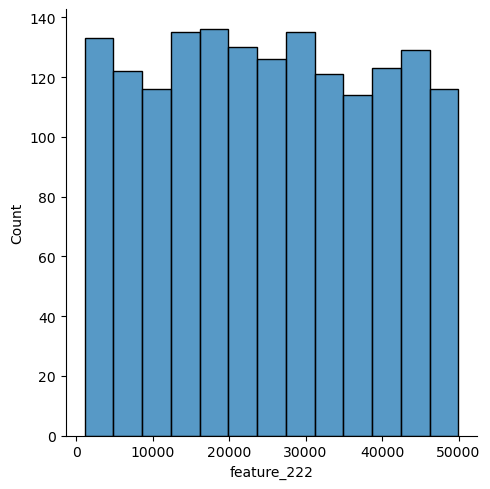

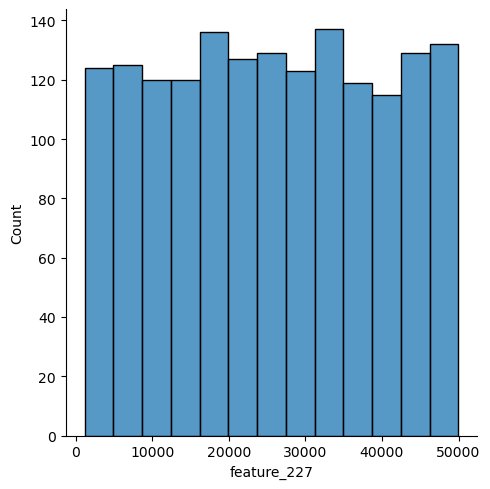

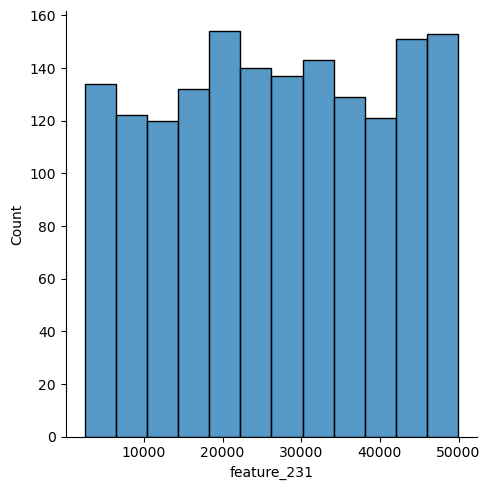

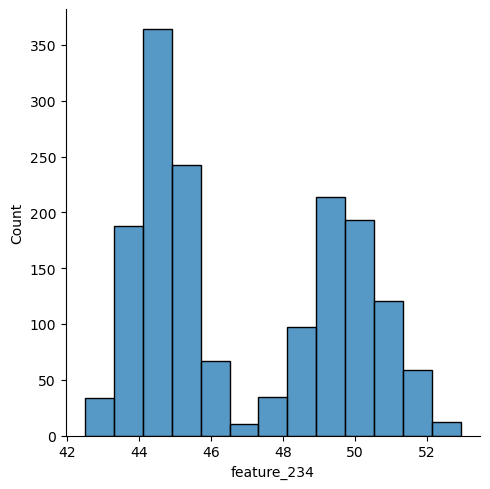

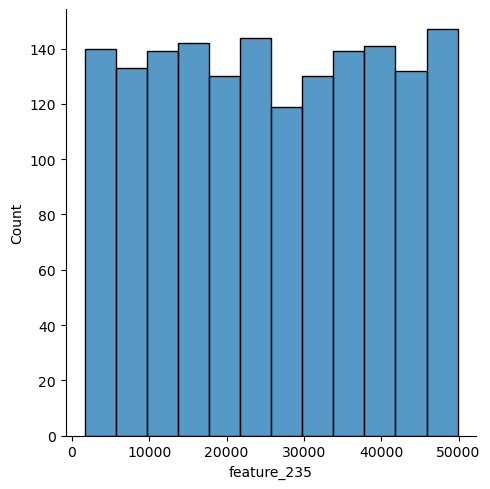

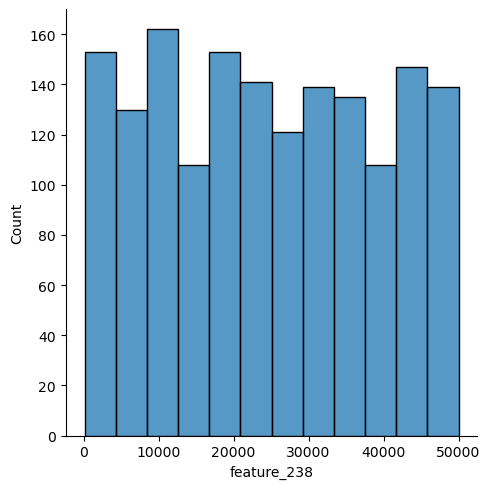

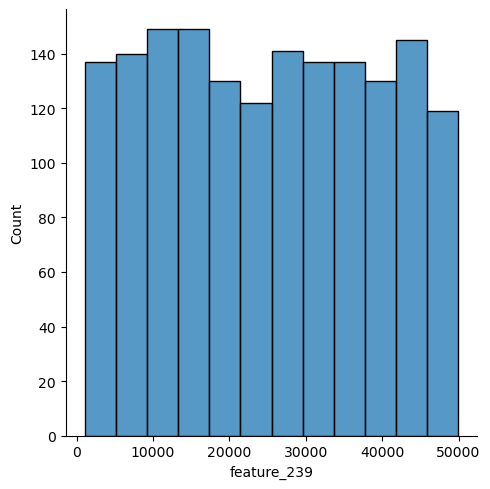

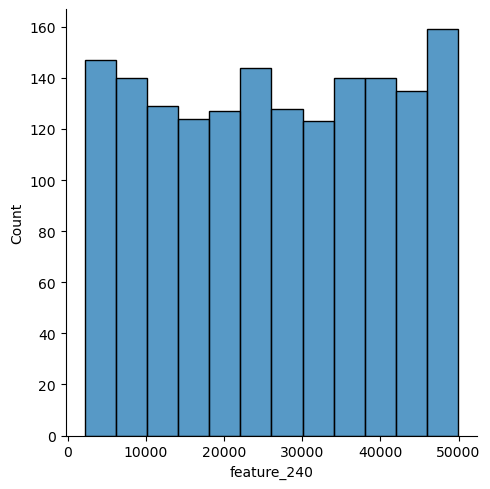

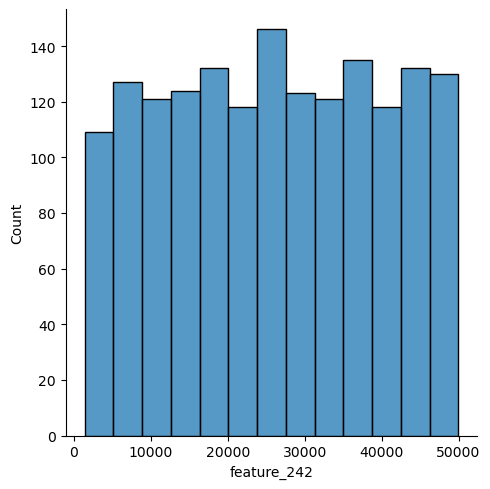

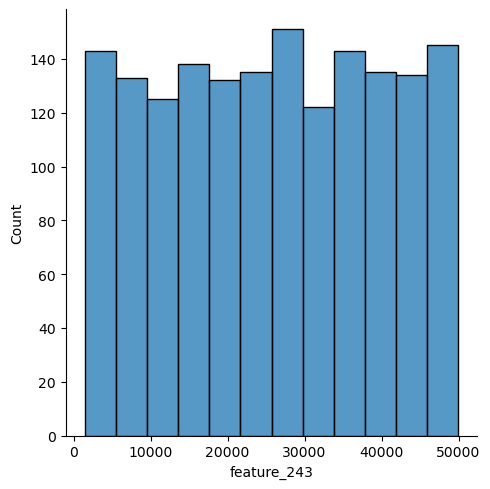

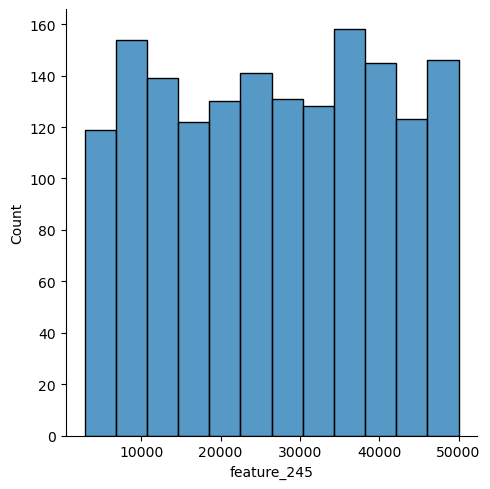

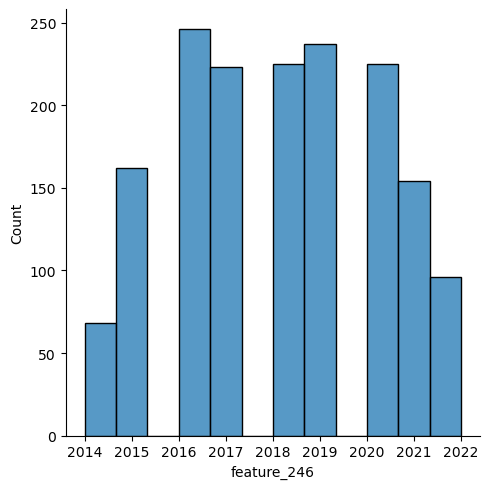

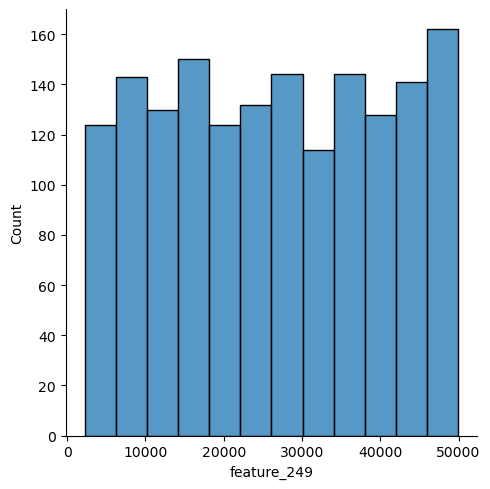

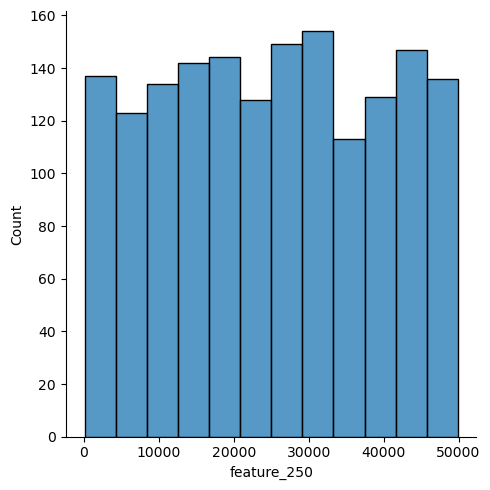

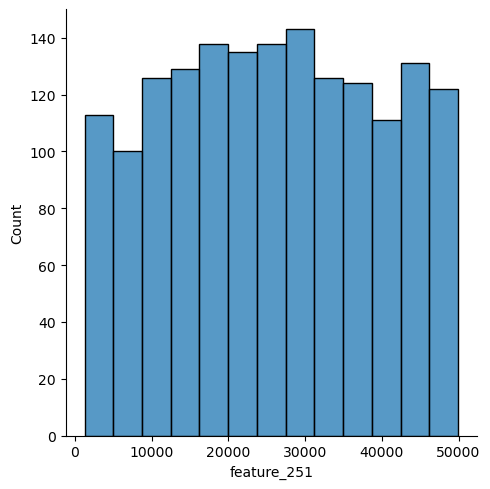

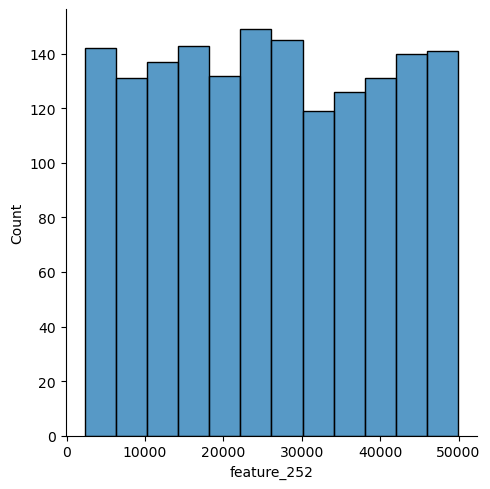

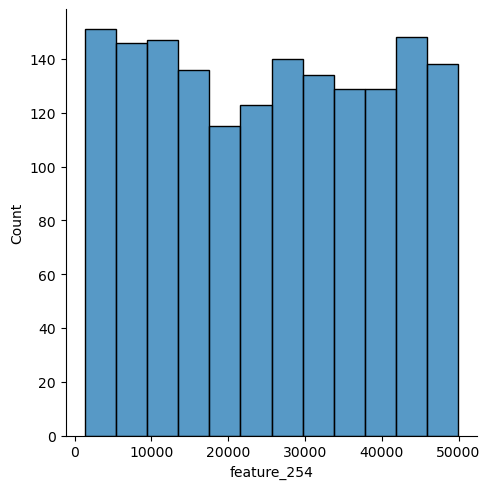

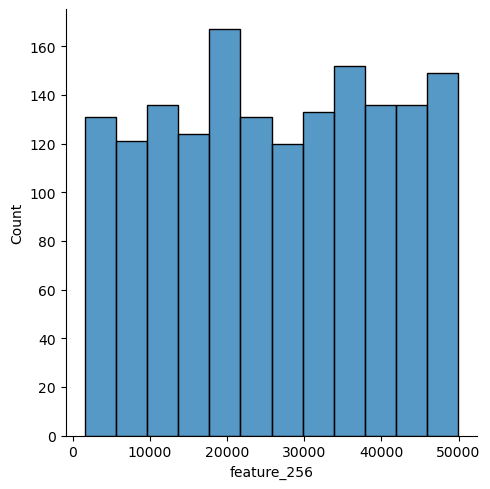

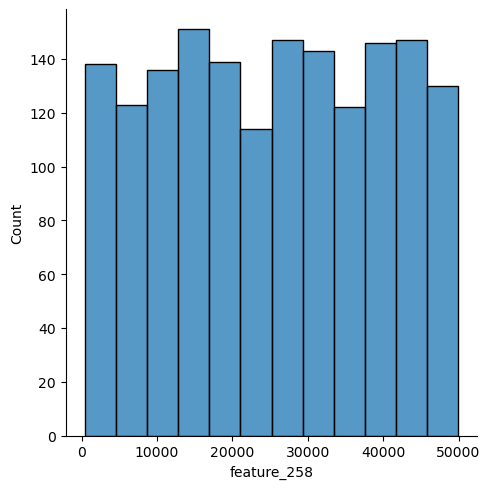

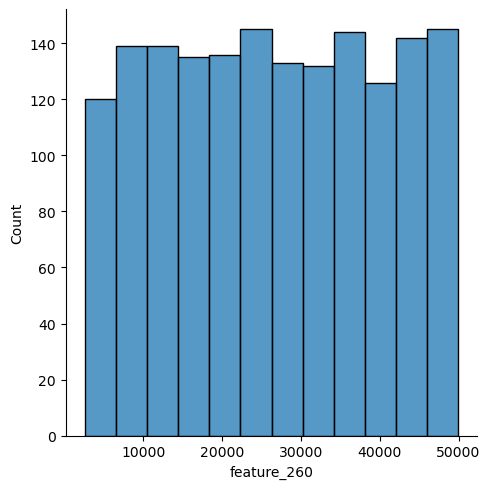

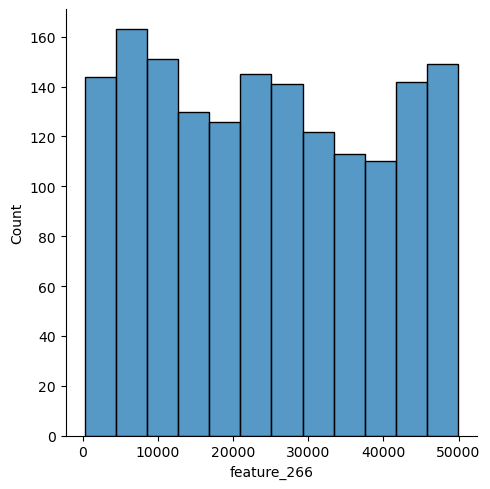

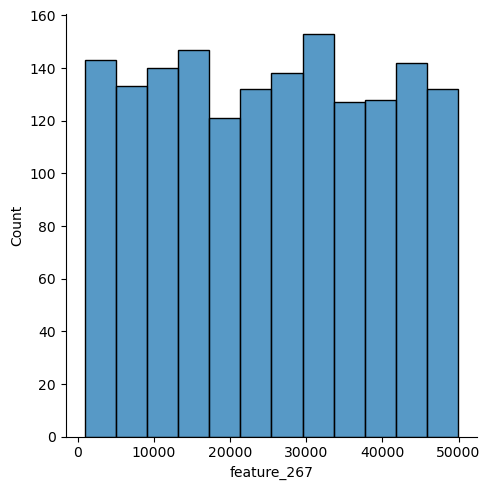

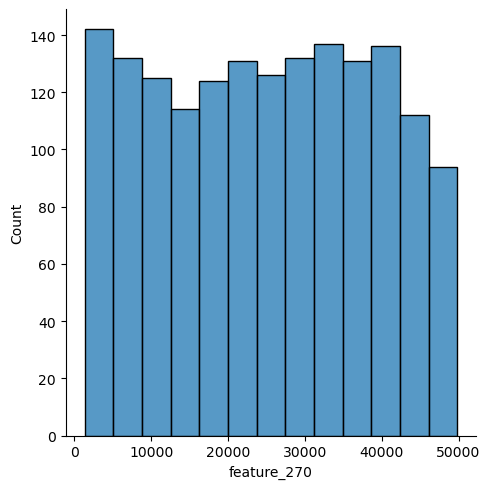

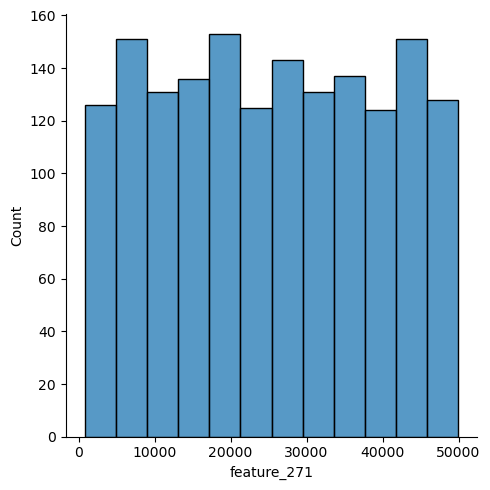

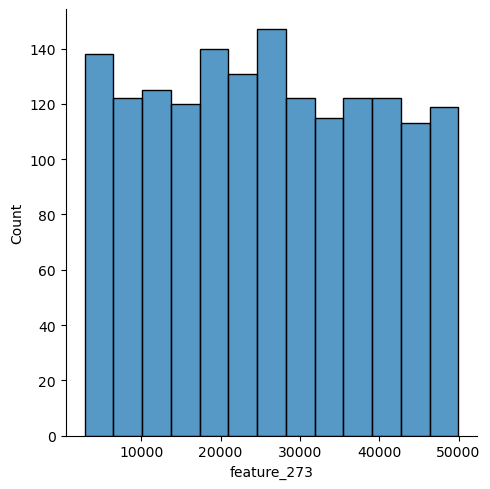

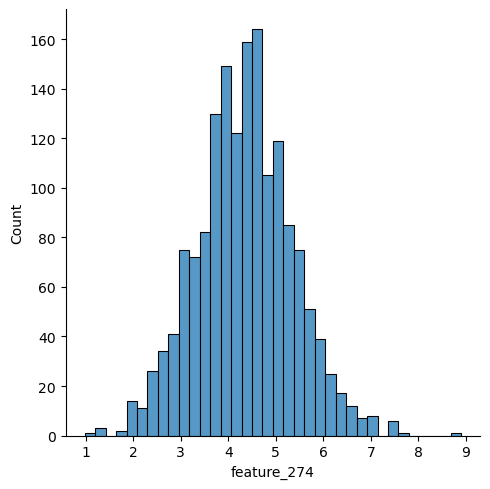

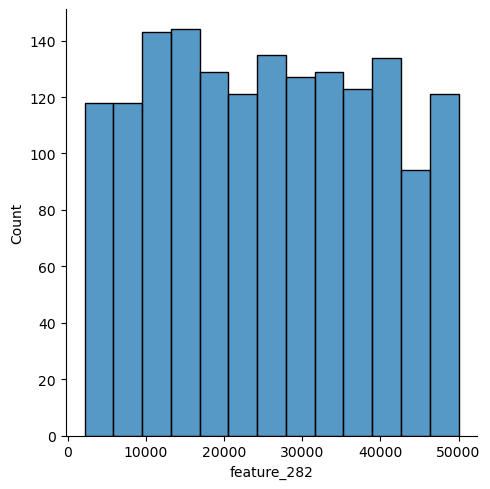

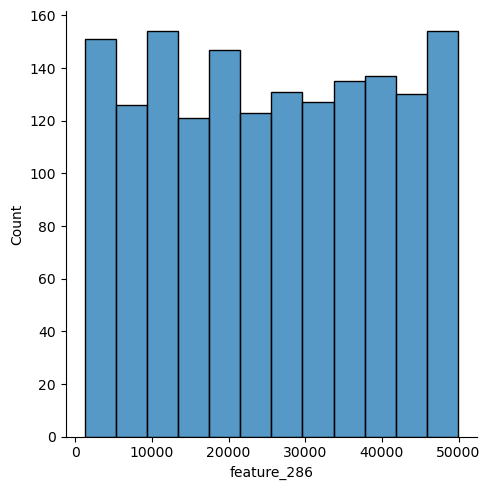

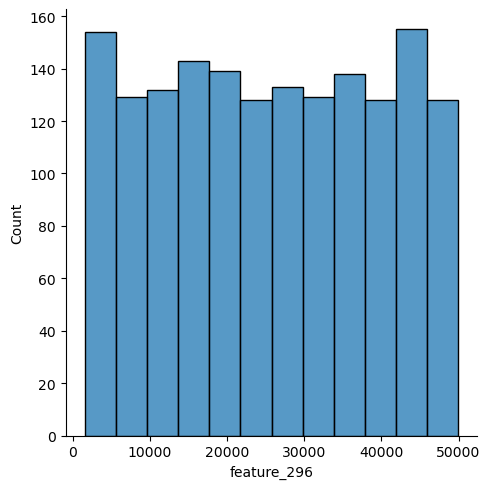

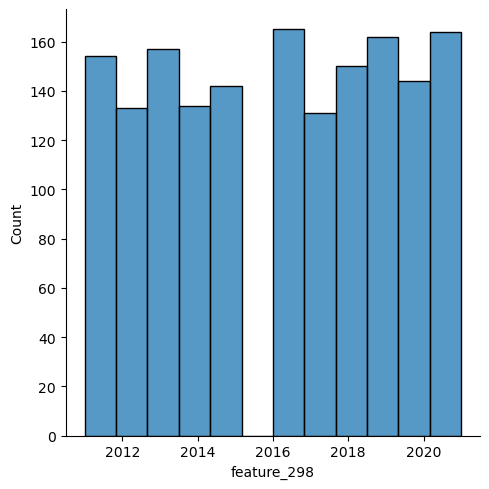

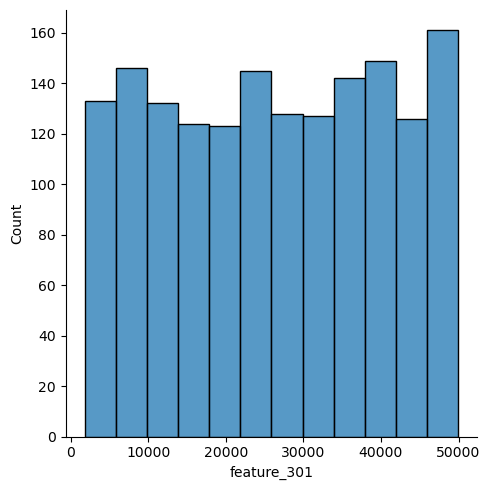

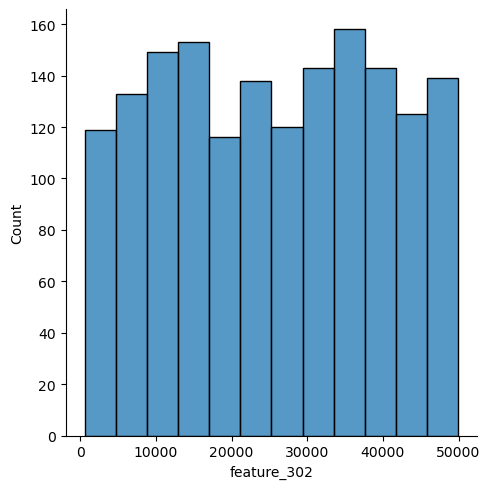

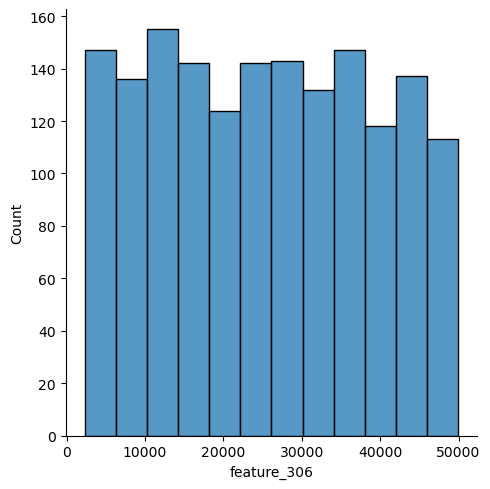

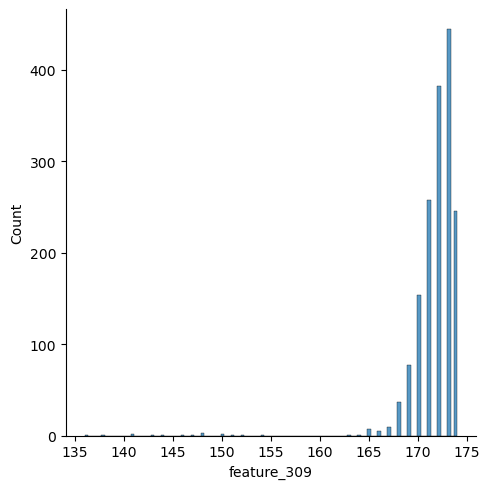

In [24]:
from scipy.stats import kstest

alpha = 0.001

for col in df.columns[:-1]:
    if kstest(df[col], 'norm')[1] < alpha:
        sns.displot(df[col])

In [ ]:
# feature_1
# feature_2
# feature_3

NameError: name 'feature_1' is not defined

In [ ]:
# ! pip install scipy==1.11.4

   ---------------------------------------- 0.0/43.7 MB ? eta -:--:--
    --------------------------------------- 1.0/43.7 MB 6.3 MB/s eta 0:00:07
   -- ------------------------------------- 3.1/43.7 MB 8.8 MB/s eta 0:00:05
   ----- ---------------------------------- 5.5/43.7 MB 9.9 MB/s eta 0:00:04
   ------- -------------------------------- 7.9/43.7 MB 10.1 MB/s eta 0:00:04
   --------- ------------------------------ 10.2/43.7 MB 10.4 MB/s eta 0:00:04
   ----------- ---------------------------- 12.8/43.7 MB 10.7 MB/s eta 0:00:03
   ------------- -------------------------- 15.2/43.7 MB 10.9 MB/s eta 0:00:03
   ---------------- ----------------------- 17.6/43.7 MB 11.1 MB/s eta 0:00:03
   ------------------ --------------------- 19.9/43.7 MB 11.1 MB/s eta 0:00:03
   -------------------- ------------------- 22.0/43.7 MB 10.9 MB/s eta 0:00:02
   --------------------- ------------------ 23.9/43.7 MB 10.8 MB/s eta 0:00:02
   ----------------------- ---------------- 25.7/43.7 MB 10.7 MB/s e